# Measuring the hawkish/dovish tone of FOMC communications

This notebook studies FOMC statements and minutes from 2000 to 2024. The goal is to measure the monetary policy signal conveyed by these documents on a hawkish/dovish axis, then relate this signal to rate decisions, financial volatility, elections, and macroeconomic regimes.


## Main takeaways

The dictionary-based tone measure is positive on average, meaning that hawkish terms dominate dovish terms over the full sample. Rate hikes are associated with the most hawkish language. High-VIX meetings are associated with a less hawkish tone. Election windows do not show a clear difference in this descriptive setup. Minutes are not simply a repetition of statements: average differences are small, but meeting-level gaps can be large. TF-IDF and dense LSA embeddings are used as robustness checks; they test whether policy information is present in the text beyond the hand-built dictionary.


## 1. NLP problem and contribution

The task is to measure a latent monetary policy signal from institutional text. A hawkish document stresses inflation, price pressures, restrictive conditions, tightening, or higher rates. A dovish document stresses support to activity, labor market weakness, easing, lower rates, or downside risks.

This is an NLP problem because the object of interest is not directly observed. It is embedded in sentences. The documents also differ strongly in length and institutional role: statements are short and immediate, while minutes are long and more detailed. The contribution of the notebook is to turn this text into reproducible tone indicators, compare statements and minutes, and study how the signal varies across policy and macro-financial contexts.


## 2. Short literature review

Central bank communication is commonly treated as a policy instrument. Blinder, Ehrmann, Fratzscher, De Haan and Jansen (2008) show that communication can move financial markets, improve predictability, and influence expectations. This motivates treating FOMC language as economic data rather than as background commentary.

Lucca and Trebbi (2009) propose an automated measure of the content of FOMC statements and show that market rates react to communication, not only to the contemporaneous rate decision. This is important here: two meetings with the same decision can still send different signals about the future path of policy.

Hansen, McMahon and Prat (2018) use computational linguistics to study FOMC deliberation and transparency. Their work confirms that Federal Reserve documents can be analyzed as structured text data. This notebook focuses on publicly available statements and minutes rather than internal transcripts.

The text-as-data literature also emphasizes that representation choices matter. Gentzkow, Kelly and Taddy (2019) discuss how text becomes economic data. Loughran and McDonald (2011) show that generic sentiment dictionaries can be misleading in financial contexts. For that reason, the notebook uses a monetary-policy dictionary rather than a generic positive/negative sentiment measure.

Main references:

- Blinder, A. S., Ehrmann, M., Fratzscher, M., De Haan, J. and Jansen, D.-J. (2008), Central Bank Communication and Monetary Policy.
- Lucca, D. O. and Trebbi, F. (2009), Measuring Central Bank Communication.
- Hansen, S., McMahon, M. and Prat, A. (2018), Transparency and Deliberation Within the FOMC.
- Gentzkow, M., Kelly, B. and Taddy, M. (2019), Text as Data.
- Loughran, T. and McDonald, B. (2011), When Is a Liability Not a Liability?


## 3. Proposed models

The main model is an expert-guided lexical score. Hawkish and dovish term lists are defined from monetary policy language. The document score is a normalized balance between the two sets.

This choice is deliberate. The sample is moderate in size, with 199 matched meetings, and there is no hand-labeled training set for hawkish/dovish language. A dictionary model is transparent, easy to audit, and directly connected to the economic concept of interest. It is also convenient for comparing statements and minutes with the same measurement tool.

The notebook uses several complementary models and checks:

1. Document-level lexical tone: the main hawkish/dovish score.
2. Masked lexical tone: the same score after removing sentences that directly announce the rate decision.
3. Sentence-level classification: sentences are tagged as hawkish, dovish, mixed, or neutral based on dictionary hits.
4. TF-IDF policy models: logistic regression and linear SVM benchmarks evaluated with a chronological split.
5. Dictionary sensitivity: the main score is compared with a stricter dictionary that removes generic terms.
6. Dense embeddings: an LSA representation is used to study document geometry, prototype similarity, and nearest neighbors; an optional Sentence-BERT block is included when the package is available.

The goal is not to maximize predictive performance. The goal is to build an interpretable signal and check whether its behavior is robust across representations.


## 4. Environment and FOMC data loading

The notebook is self-contained. If processed FOMC features are missing, it rebuilds them from `data/raw/fomc_documents_raw.csv`. If the raw FOMC file is also missing, it collects links and texts from the Federal Reserve website. If the VIX file is missing, it downloads it from Cboe.


In [194]:
from __future__ import annotations

import os
import re
import string
from datetime import date
from pathlib import Path
from time import sleep
from urllib.parse import urljoin
from urllib.request import Request, urlopen

import matplotlib

if os.environ.get("MPLBACKEND") == "Agg":
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from bs4 import BeautifulSoup
from IPython.display import display
from scipy import stats
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = ROOT / "figures" / "signal_analysis"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

print(ROOT)


/Users/mathieu/Documents/Ensae/3A/Cours/S2/Machine Learning for NLP/ml_for_nlp


### Self-contained collection and NLP helpers

The following functions replace local package imports. The notebook can run even if `src/fomc_nlp/features.py`, `preprocessing.py`, or `visualization.py` are absent. Existing raw CSV files are reused when available; otherwise the notebook collects the official Fed documents and reconstructs the features needed for the analysis.


In [195]:
FED_BASE_URL = "https://www.federalreserve.gov"
FOMC_CALENDAR_URL = f"{FED_BASE_URL}/monetarypolicy/fomccalendars.htm"

MONTHS = {
    "jan": 1, "january": 1, "feb": 2, "february": 2, "mar": 3, "march": 3,
    "apr": 4, "april": 4, "may": 5, "jun": 6, "june": 6, "jul": 7, "july": 7,
    "aug": 8, "august": 8, "sep": 9, "sept": 9, "september": 9,
    "oct": 10, "october": 10, "nov": 11, "november": 11, "dec": 12, "december": 12,
}
DATE_IN_URL_RE = re.compile(r"(?P<ymd>(?:19|20)\d{6})")
HISTORICAL_HEADING_RE = re.compile(
    r"(?P<date_text>[A-Za-z/]+\s+\d{1,2}(?:\s*-\s*(?:[A-Za-z]+\s*)?\d{1,2})?)\s+Meeting\s+-\s+(?P<year>\d{4})",
    re.IGNORECASE,
)

HAWKISH_TERMS = [
    "inflation", "price stability", "elevated", "tightening", "restrictive", "firming",
    "increase", "increased", "increases", "pressure", "pressures", "overheating",
    "strong labor market", "higher rates", "persistent inflation", "inflationary pressures",
]
DOVISH_TERMS = [
    "unemployment", "slowdown", "weakness", "accommodative", "support", "downside risks",
    "lower rates", "easing", "recession", "recovery", "labor market slack", "weak demand",
    "economic weakness",
]
UNCERTAINTY_TERMS = [
    "uncertainty", "uncertain", "risks", "risk", "downside", "upside", "volatility",
    "financial conditions", "stress", "disruptions", "concerns", "monitor", "likely", "may", "could",
]
DECISION_MASK_PATTERNS = [
    "decided to raise", "decided to lower", "decided to maintain", "decided to keep",
    "target range", "federal funds rate", "increase the target", "decrease the target",
    "raise the target", "lower the target", "keep the target", "left unchanged", "voted to",
]
RATE_DECISION_PATTERNS = {
    "hike": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(raise|raising|increase|increasing)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(raise|raising|increase|increasing|increased)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "cut": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "hold": [
        r"\b(decided|voted|agreed)\b.{0,80}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(will|would|shall|to)\b.{0,20}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(maintain|maintaining|keep|keeping|kept|leave|leaving)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(target range|target for the federal funds rate|federal funds rate)\b.{0,80}\b(unchanged|maintained)\b",
    ],
}

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?", re.IGNORECASE)
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")

def clean_text(text: str | float | None) -> str:
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""
    text = str(text)
    text = text.replace("\u00a0", " ")
    text = text.replace("\u2019", "'").replace("\u2018", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = text.replace("\u2013", "-").replace("\u2014", "-")
    text = text.lower()
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def tokenize_text(text: str | float | None) -> list[str]:
    return TOKEN_RE.findall(clean_text(text))

def count_words(text: str | float | None) -> int:
    return len(tokenize_text(text))

def split_sentences(text: str | float | None) -> list[str]:
    cleaned = str(text or "").strip()
    if not cleaned:
        return []
    return [sentence.strip() for sentence in SENTENCE_SPLIT_RE.split(cleaned) if sentence.strip()]

def count_sentences(text: str | float | None) -> int:
    return len(split_sentences(text))

def mask_decision_sentences(text: str | float | None, mask_token: str = "[DECISION_MASKED]") -> str:
    compiled = [re.compile(rf"\b{re.escape(pattern.lower())}\b", re.IGNORECASE) for pattern in DECISION_MASK_PATTERNS]
    output = []
    for sentence in split_sentences(text):
        sentence_lower = sentence.lower()
        output.append(mask_token if any(pattern.search(sentence_lower) for pattern in compiled) else sentence)
    return " ".join(output)

def _term_pattern(term: str) -> re.Pattern[str]:
    escaped = re.escape(term.lower()).replace(r"\ ", r"\s+")
    return re.compile(rf"(?<![a-z]){escaped}(?![a-z])", flags=re.IGNORECASE)

def count_dictionary_terms(text: str | float | None, terms: list[str]) -> int:
    cleaned = clean_text(text)
    return sum(len(_term_pattern(term).findall(cleaned)) for term in terms)

def infer_rate_decision(text: str | None) -> str:
    cleaned = clean_text(text)
    if not cleaned:
        return "unknown"
    for label in ["hike", "cut", "hold"]:
        for pattern in RATE_DECISION_PATTERNS[label]:
            if re.search(pattern, cleaned, flags=re.IGNORECASE | re.DOTALL):
                return label
    return "unknown"


In [196]:
def fetch_html(url: str, timeout: int = 30) -> str:
    response = requests.get(
        url,
        timeout=timeout,
        headers={"User-Agent": "ml-for-nlp-fomc-project/1.0"},
    )
    response.raise_for_status()
    response.encoding = response.apparent_encoding or response.encoding
    return response.text

def parse_date_from_url(url: str) -> str | None:
    match = DATE_IN_URL_RE.search(url)
    if not match:
        return None
    ymd = match.group("ymd")
    return f"{ymd[:4]}-{ymd[4:6]}-{ymd[6:]}"

def parse_meeting_date(date_text: str, year: int) -> str:
    date_text = re.sub(r"\s+", " ", date_text.replace("*", "").strip())
    match = re.match(
        r"(?P<month1>[A-Za-z]+)(?:/(?P<slash_month2>[A-Za-z]+))?\s+"
        r"(?P<day1>\d{1,2})"
        r"(?:\s*-\s*(?:(?P<month2>[A-Za-z]+)\s*)?(?P<day2>\d{1,2}))?$",
        date_text,
    )
    if not match:
        raise ValueError(f"Cannot parse meeting date: {date_text!r}")
    month1 = MONTHS[match.group("month1").lower()]
    day1 = int(match.group("day1"))
    slash_month2_text = match.group("slash_month2")
    month2_text = match.group("month2")
    day2_text = match.group("day2")
    if month2_text:
        month = MONTHS[month2_text.lower()]
    elif slash_month2_text and day2_text and int(day2_text) < day1:
        month = MONTHS[slash_month2_text.lower()]
    else:
        month = month1
    day = int(day2_text) if day2_text else day1
    parsed_year = year
    if day2_text and month2_text is None and day < day1 and month1 == 12:
        parsed_year += 1
    return date(parsed_year, month, day).isoformat()

def _historical_year_url(year: int) -> str:
    return f"{FED_BASE_URL}/monetarypolicy/fomchistorical{year}.htm"

def _normalize_space(value: str) -> str:
    return re.sub(r"\s+", " ", value).strip()

def _parse_historical_year_page(year: int, html: str) -> list[dict[str, object]]:
    soup = BeautifulSoup(html, "html.parser")
    meetings = []
    for panel in soup.select("div.panel"):
        heading = panel.select_one(".panel-heading") or panel.find(["h3", "h4", "h5", "h6"])
        if heading is None:
            continue
        heading_text = _normalize_space(heading.get_text(" ", strip=True))
        match = HISTORICAL_HEADING_RE.search(heading_text)
        if not match:
            continue
        meeting_date = parse_meeting_date(match.group("date_text"), int(match.group("year")))
        row = {
            "date": meeting_date,
            "year": int(meeting_date[:4]),
            "meeting_id": meeting_date,
            "statement_url": None,
            "minutes_url": None,
        }
        for link in panel.find_all("a", href=True):
            label = _normalize_space(link.get_text(" ", strip=True)).lower()
            href = urljoin(FED_BASE_URL, link["href"])
            href_lower = href.lower()
            if label == "statement":
                row["statement_url"] = href
            is_minutes_link = (
                label == "minutes"
                or ("fomcminutes" in href_lower and href_lower.endswith(".htm"))
                or ("/fomc/minutes/" in href_lower and href_lower.endswith(".htm"))
                or bool(re.search(r"/monetarypolicy/fomc\d{8}\.htm$", href_lower))
            )
            link_date = parse_date_from_url(href)
            if is_minutes_link and (link_date is None or link_date == meeting_date):
                row["minutes_url"] = href
        meetings.append(row)
    return meetings

def _parse_current_calendar_page(html: str, start_year: int, end_year: int) -> list[dict[str, object]]:
    soup = BeautifulSoup(html, "html.parser")
    by_date = {}
    for link in soup.find_all("a", href=True):
        href = urljoin(FED_BASE_URL, link["href"])
        url_lower = href.lower()
        label = _normalize_space(link.get_text(" ", strip=True)).lower()
        meeting_date = parse_date_from_url(href)
        if not meeting_date:
            continue
        year = int(meeting_date[:4])
        if year < start_year or year > end_year:
            continue
        document_type = None
        if "fomcminutes" in url_lower and label == "html":
            document_type = "minutes"
        elif "/pressreleases/monetary" in url_lower and label == "html":
            document_type = "statement"
        elif "fomcstatement" in url_lower and label == "html":
            document_type = "statement"
        if document_type is None:
            continue
        by_date.setdefault(
            meeting_date,
            {"date": meeting_date, "year": year, "meeting_id": meeting_date, "statement_url": None, "minutes_url": None},
        )
        by_date[meeting_date][f"{document_type}_url"] = href
    return list(by_date.values())

def collect_fomc_meeting_links(start_year: int = 2000, end_year: int = 2024) -> pd.DataFrame:
    meetings = []
    for year in range(start_year, min(end_year, 2020) + 1):
        html = fetch_html(_historical_year_url(year))
        meetings.extend(_parse_historical_year_page(year, html))
        sleep(0.1)
    if end_year >= 2021:
        html = fetch_html(FOMC_CALENDAR_URL)
        meetings.extend(_parse_current_calendar_page(html, max(start_year, 2021), end_year))
    df = pd.DataFrame(meetings)
    if df.empty:
        return pd.DataFrame(columns=["date", "year", "meeting_id", "statement_url", "minutes_url"])
    return df.drop_duplicates(subset=["date"], keep="last").sort_values("date").reset_index(drop=True)

def _extract_main_text(html: str) -> str:
    soup = BeautifulSoup(html, "html.parser")
    for tag in soup(["script", "style", "noscript", "nav", "header", "footer"]):
        tag.decompose()
    candidates = []
    for selector in ["div.article__content", "div#article", "article", "main", "body"]:
        node = soup.select_one(selector)
        if node is not None:
            text = node.get_text(" ", strip=True)
            if len(text) > 100:
                candidates.append(text)
    if not candidates:
        candidates.append(soup.get_text(" ", strip=True))
    return re.sub(r"\s+", " ", max(candidates, key=len)).strip()

def download_document_text(url: str) -> str:
    if not isinstance(url, str) or not url.strip():
        return ""
    if url.lower().endswith(".pdf"):
        raise ValueError(f"PDF extraction is not enabled for {url}; prefer Fed HTML links.")
    return _extract_main_text(fetch_html(url))

def collect_raw_fomc_documents(start_year: int = 2000, end_year: int = 2024) -> pd.DataFrame:
    links = collect_fomc_meeting_links(start_year, end_year)
    links.to_csv(RAW_DIR / "fomc_meeting_links.csv", index=False)
    rows = []
    for row in links.to_dict(orient="records"):
        if pd.isna(row.get("statement_url")) or pd.isna(row.get("minutes_url")):
            continue
        output = dict(row)
        for document_type in ["statement", "minutes"]:
            url = output.get(f"{document_type}_url")
            try:
                output[f"{document_type}_text"] = download_document_text(str(url))
                output[f"{document_type}_download_error"] = ""
            except Exception as exc:
                output[f"{document_type}_text"] = ""
                output[f"{document_type}_download_error"] = str(exc)
            sleep(0.1)
        rows.append(output)
    raw = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    raw.to_csv(RAW_DIR / "fomc_documents_raw.csv", index=False)
    return raw


In [197]:
def add_basic_text_columns(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    for corpus in ["statement", "minutes"]:
        text_col = f"{corpus}_text"
        clean_col = f"{corpus}_clean_text"
        masked_col = f"{corpus}_masked_text"
        masked_clean_col = f"{corpus}_masked_clean_text"
        n_words_col = f"{corpus}_n_words"
        n_sentences_col = f"{corpus}_n_sentences"
        if text_col not in result.columns:
            result[text_col] = ""
        result[clean_col] = result[text_col].map(clean_text)
        result[masked_col] = result[text_col].map(mask_decision_sentences)
        result[masked_clean_col] = result[masked_col].map(clean_text)
        result[n_words_col] = result[text_col].map(count_words).astype(int)
        result[n_sentences_col] = result[text_col].map(count_sentences).astype(int)
    if "rate_decision" not in result.columns:
        result["rate_decision"] = result["statement_text"].map(infer_rate_decision)
    else:
        result["rate_decision"] = result["rate_decision"].fillna(result["statement_text"].map(infer_rate_decision))
    return result

def add_dictionary_scores(df: pd.DataFrame, corpus: str) -> pd.DataFrame:
    result = df.copy()
    text_col = f"{corpus}_clean_text"
    n_words = result[f"{corpus}_n_words"].replace(0, np.nan)
    hawkish_counts = result[text_col].map(lambda text: count_dictionary_terms(text, HAWKISH_TERMS))
    dovish_counts = result[text_col].map(lambda text: count_dictionary_terms(text, DOVISH_TERMS))
    uncertainty_counts = result[text_col].map(lambda text: count_dictionary_terms(text, UNCERTAINTY_TERMS))
    result[f"{corpus}_hawkish_count"] = hawkish_counts
    result[f"{corpus}_dovish_count"] = dovish_counts
    result[f"{corpus}_hawkish_score"] = (hawkish_counts / n_words).fillna(0.0)
    result[f"{corpus}_dovish_score"] = (dovish_counts / n_words).fillna(0.0)
    result[f"{corpus}_tone_score"] = result[f"{corpus}_hawkish_score"] - result[f"{corpus}_dovish_score"]
    result[f"{corpus}_uncertainty_count"] = uncertainty_counts
    result[f"{corpus}_uncertainty_score"] = (uncertainty_counts / n_words).fillna(0.0)
    return result

def build_tfidf_matrix(texts: list[str], min_df: int = 1, max_features: int = 5000):
    vectorizer = TfidfVectorizer(stop_words="english", min_df=min_df, max_features=max_features, ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([clean_text(text) for text in texts])
    return matrix, vectorizer

def compute_within_corpus_semantic_shift(df: pd.DataFrame, text_col: str, prefix: str) -> pd.DataFrame:
    result = df.sort_values("date").reset_index(drop=True).copy()
    shift_col = f"{prefix}_semantic_shift_tfidf"
    similarity_col = f"{prefix}_successive_similarity_tfidf"
    result[shift_col] = np.nan
    result[similarity_col] = np.nan
    valid_mask = result[text_col].fillna("").str.len().gt(0)
    if valid_mask.sum() < 2:
        return result
    valid_index = result.index[valid_mask].to_list()
    matrix, _ = build_tfidf_matrix(result.loc[valid_index, text_col].tolist())
    for position in range(1, matrix.shape[0]):
        similarity = cosine_similarity(matrix[position], matrix[position - 1])[0, 0]
        row_index = valid_index[position]
        result.loc[row_index, similarity_col] = similarity
        result.loc[row_index, shift_col] = 1.0 - similarity
    return result

def compute_statement_minutes_similarity(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["same_meeting_similarity_tfidf"] = np.nan
    result["same_meeting_distance_tfidf"] = np.nan
    valid = result["statement_clean_text"].fillna("").str.len().gt(0) & result["minutes_clean_text"].fillna("").str.len().gt(0)
    if not valid.any():
        return result
    valid_indices = result.index[valid].to_list()
    statement_texts = result.loc[valid_indices, "statement_clean_text"].tolist()
    minutes_texts = result.loc[valid_indices, "minutes_clean_text"].tolist()
    matrix, _ = build_tfidf_matrix(statement_texts + minutes_texts)
    n = len(valid_indices)
    for i, row_index in enumerate(valid_indices):
        similarity = cosine_similarity(matrix[i], matrix[i + n])[0, 0]
        result.loc[row_index, "same_meeting_similarity_tfidf"] = similarity
        result.loc[row_index, "same_meeting_distance_tfidf"] = 1.0 - similarity
    return result

def export_processed_tables(merged: pd.DataFrame) -> None:
    statement_cols = [
        "date", "year", "meeting_id", "statement_url", "statement_text", "statement_clean_text",
        "statement_n_words", "rate_decision", "statement_download_error",
    ]
    minutes_cols = [
        "date", "year", "meeting_id", "minutes_url", "minutes_text", "minutes_clean_text",
        "minutes_n_words", "minutes_download_error",
    ]
    merged[[c for c in statement_cols if c in merged.columns]].to_csv(PROCESSED_DIR / "fomc_statements.csv", index=False)
    merged[[c for c in minutes_cols if c in merged.columns]].to_csv(PROCESSED_DIR / "fomc_minutes.csv", index=False)
    merged.to_csv(PROCESSED_DIR / "fomc_merged.csv", index=False)

def build_feature_dataset(raw_documents: pd.DataFrame) -> pd.DataFrame:
    result = add_basic_text_columns(raw_documents)
    for corpus in ["statement", "minutes"]:
        result = add_dictionary_scores(result, corpus)
    statement_shift = compute_within_corpus_semantic_shift(
        result[["date", "statement_clean_text"]].copy(), "statement_clean_text", "statement"
    )
    minutes_shift = compute_within_corpus_semantic_shift(
        result[["date", "minutes_clean_text"]].copy(), "minutes_clean_text", "minutes"
    )
    result = result.merge(
        statement_shift[["date", "statement_successive_similarity_tfidf", "statement_semantic_shift_tfidf"]],
        on="date", how="left",
    )
    result = result.merge(
        minutes_shift[["date", "minutes_successive_similarity_tfidf", "minutes_semantic_shift_tfidf"]],
        on="date", how="left",
    )
    result = compute_statement_minutes_similarity(result)
    result = result.sort_values("date").reset_index(drop=True)
    export_processed_tables(result)
    result.to_csv(PROCESSED_DIR / "fomc_features.csv", index=False)
    return result

def load_or_build_fomc_features(start_year: int = 2000, end_year: int = 2024, force_rebuild: bool = False) -> pd.DataFrame:
    features_path = PROCESSED_DIR / "fomc_features.csv"
    raw_path = RAW_DIR / "fomc_documents_raw.csv"
    if features_path.exists() and not force_rebuild:
        return pd.read_csv(features_path, dtype={"date": str})
    if raw_path.exists() and not force_rebuild:
        raw = pd.read_csv(raw_path, dtype={"date": str})
        raw = raw.dropna(subset=["statement_text", "minutes_text"]).copy()
        return build_feature_dataset(raw)
    raw = collect_raw_fomc_documents(start_year=start_year, end_year=end_year)
    raw = raw.dropna(subset=["statement_text", "minutes_text"]).copy()
    return build_feature_dataset(raw)


In [198]:
fomc = load_or_build_fomc_features(start_year=2000, end_year=2024)
fomc["date_dt"] = pd.to_datetime(fomc["date"])
fomc = fomc.sort_values("date_dt").reset_index(drop=True)

print(f"Meetings: {len(fomc)}")
print(f"Period: {fomc['date'].min()} to {fomc['date'].max()}")
display(fomc["rate_decision"].value_counts().rename_axis("rate_decision").to_frame("n"))


Meetings: 199
Period: 2000-02-02 to 2024-12-18


,n
rate_decision,
hold,110
hike,59
cut,30


## 5. Corpus description

This section checks the size of the sample, rate-decision counts, document lengths, and missing values. The length difference between statements and minutes is important: minutes provide more context but also more opportunities for dictionary hits, so all lexical scores are normalized by document length.


In [199]:
doc_description_rows = []
for corpus in ["statement", "minutes"]:
    tmp = fomc[["date", "year", "rate_decision", f"{corpus}_n_words", f"{corpus}_n_sentences"]].copy()
    tmp = tmp.rename(columns={f"{corpus}_n_words": "n_words", f"{corpus}_n_sentences": "n_sentences"})
    tmp["document_type"] = corpus
    doc_description_rows.append(tmp)

doc_description = pd.concat(doc_description_rows, ignore_index=True)

length_summary = (
    doc_description.groupby("document_type")[["n_words", "n_sentences"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(1)
)
display(length_summary)

missing_summary = fomc[
    ["statement_clean_text", "minutes_clean_text", "statement_n_words", "minutes_n_words"]
].isna().sum().rename("missing_values").to_frame()
display(missing_summary)

meetings_by_year = fomc.groupby("year").size().rename("n_meetings").reset_index()
display(meetings_by_year.head(), meetings_by_year.tail())


n_words                                      n_sentences         \
                count    mean  median     std   min    max       count   mean   
document_type                                                                   
minutes           199  7282.7  7518.0  2440.5  3262  14505         199  311.9   
statement         199   526.1   536.0   217.4   145   1078         199   26.8   

                                      
              median   std  min  max  
document_type                         
minutes        318.0  93.6  164  605  
statement       29.0   7.8    6   39

,missing_values
statement_clean_text,0
minutes_clean_text,0
statement_n_words,0
minutes_n_words,0


,year,n_meetings
0,2000,8
1,2001,8
2,2002,8
3,2003,8
4,2004,8


,year,n_meetings
20,2020,7
21,2021,8
22,2022,8
23,2023,8
24,2024,8


## 6. Context variables: VIX, elections, and macro regimes

The VIX is used as a proxy for financial volatility. For each FOMC meeting, the notebook computes the mean and maximum VIX in a calendar window from five days before to five days after the meeting. Election windows are coded within 90 days of U.S. presidential and midterm elections. Macro regimes are simple historical bins used for interpretation rather than estimated states.


In [200]:
VIX_URL = "https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX_History.csv"
vix_path = RAW_DIR / "vix_daily_cboe.csv"

if not vix_path.exists():
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    req = Request(VIX_URL, headers={"User-Agent": "ml-for-nlp-fomc-project/1.0"})
    with urlopen(req, timeout=30) as response:
        vix_path.write_bytes(response.read())

vix = pd.read_csv(vix_path)
vix.columns = [column.lower() for column in vix.columns]
vix["date_dt"] = pd.to_datetime(vix["date"], format="%m/%d/%Y")
vix = vix.sort_values("date_dt").reset_index(drop=True)
vix = vix.loc[vix["date_dt"].between("2000-01-01", "2024-12-31")].copy()

print(f"VIX observations: {len(vix)}")
print(f"VIX period: {vix['date_dt'].min().date()} to {vix['date_dt'].max().date()}")
display(vix.head())


VIX observations: 6309
VIX period: 2000-01-03 to 2024-12-31


,date,open,high,low,close,date_dt
2524,01/03/2000,24.36,26.15,23.98,24.21,2000-01-03
2525,01/04/2000,24.94,27.18,24.80,27.01,2000-01-04
2526,01/05/2000,27.98,29.00,25.85,26.41,2000-01-05
2527,01/06/2000,26.68,26.71,24.70,25.73,2000-01-06
2528,01/07/2000,25.14,25.17,21.72,21.72,2000-01-07


In [201]:
def vix_around_meeting(meeting_date: pd.Timestamp, window_days: int = 5) -> pd.Series:
    window = vix.loc[
        vix["date_dt"].between(
            meeting_date - pd.Timedelta(days=window_days),
            meeting_date + pd.Timedelta(days=window_days),
        )
    ]
    return pd.Series(
        {
            "vix_window_mean": window["close"].mean(),
            "vix_window_max": window["close"].max(),
            "vix_window_n_obs": len(window),
        }
    )

vix_features = fomc["date_dt"].apply(vix_around_meeting)
fomc = pd.concat([fomc, vix_features], axis=1)
fomc["high_vix_30"] = fomc["vix_window_mean"].ge(30)
fomc["high_vix_q75"] = fomc["vix_window_mean"].ge(fomc["vix_window_mean"].quantile(0.75))
fomc["vix_regime"] = pd.qcut(
    fomc["vix_window_mean"],
    q=3,
    labels=["low", "medium", "high"],
)

presidential_elections = pd.to_datetime(
    ["2000-11-07", "2004-11-02", "2008-11-04", "2012-11-06", "2016-11-08", "2020-11-03", "2024-11-05"]
)
midterm_elections = pd.to_datetime(
    ["2002-11-05", "2006-11-07", "2010-11-02", "2014-11-04", "2018-11-06", "2022-11-08"]
)

def near_election(date: pd.Timestamp, election_dates: pd.DatetimeIndex, days: int = 90) -> bool:
    return any(abs((date - election_date).days) <= days for election_date in election_dates)

fomc["presidential_election_window"] = fomc["date_dt"].map(lambda date: near_election(date, presidential_elections))
fomc["midterm_election_window"] = fomc["date_dt"].map(lambda date: near_election(date, midterm_elections))
fomc["any_election_window"] = fomc["presidential_election_window"] | fomc["midterm_election_window"]

def macro_regime(date: pd.Timestamp) -> str:
    if pd.Timestamp("2001-01-01") <= date <= pd.Timestamp("2003-06-30"):
        return "dotcom_2001_easing"
    if pd.Timestamp("2007-08-01") <= date <= pd.Timestamp("2009-06-30"):
        return "global_financial_crisis"
    if pd.Timestamp("2009-07-01") <= date <= pd.Timestamp("2015-12-15"):
        return "zlb_recovery"
    if pd.Timestamp("2015-12-16") <= date <= pd.Timestamp("2019-12-31"):
        return "normalization_2015_2019"
    if pd.Timestamp("2020-03-01") <= date <= pd.Timestamp("2021-03-31"):
        return "covid_crisis"
    if pd.Timestamp("2021-04-01") <= date <= pd.Timestamp("2024-12-31"):
        return "post_covid_inflation_tightening"
    return "baseline_expansion"

fomc["macro_regime"] = fomc["date_dt"].map(macro_regime)

context_cols = [
    "date", "rate_decision", "vix_window_mean", "vix_window_max", "vix_regime",
    "high_vix_30", "high_vix_q75", "presidential_election_window",
    "midterm_election_window", "any_election_window", "macro_regime",
]
display(fomc[context_cols].head())


,date,rate_decision,vix_window_mean,vix_window_max,vix_regime,high_vix_30,high_vix_q75,presidential_election_window,midterm_election_window,any_election_window,macro_regime
0,2000-02-02,hike,23.428571,26.14,high,False,True,False,False,False,baseline_expansion
1,2000-03-21,hike,22.122857,23.31,high,False,False,False,False,False,baseline_expansion
2,2000-05-16,hike,25.198571,27.76,high,False,True,False,False,False,baseline_expansion
3,2000-06-28,hold,20.850000,22.45,medium,False,False,False,False,False,baseline_expansion
4,2000-08-22,hold,17.185714,17.48,medium,False,False,True,False,True,baseline_expansion


## 7. Hawkish/Dovish tone indicators

The pipeline first computes dictionary scores:

$$
\text{ToneScore}_{d,t} = \text{HawkishShare}_{d,t} - \text{DovishShare}_{d,t}.
$$

The main measure used below is the normalized balance:

$$
\text{ToneNorm}_{d,t} = \frac{\text{HawkishShare}_{d,t} - \text{DovishShare}_{d,t}}{\text{HawkishShare}_{d,t} + \text{DovishShare}_{d,t}}.
$$

A positive value means a more hawkish signal.  
A negative value means a more dovish signal.  
A value close to zero means a balanced document.  

The masked version removes sentences that directly reveal the rate decision.


In [202]:
print("Hawkish dictionary:")
print(", ".join(HAWKISH_TERMS))
print("\nDovish dictionary:")
print(", ".join(DOVISH_TERMS))


Hawkish dictionary:
inflation, price stability, elevated, tightening, restrictive, firming, increase, increased, increases, pressure, pressures, overheating, strong labor market, higher rates, persistent inflation, inflationary pressures

Dovish dictionary:
unemployment, slowdown, weakness, accommodative, support, downside risks, lower rates, easing, recession, recovery, labor market slack, weak demand, economic weakness


In [203]:
def normalized_balance(pos: pd.Series, neg: pd.Series) -> pd.Series:
    denominator = (pos + neg).replace(0, np.nan)
    return ((pos - neg) / denominator).fillna(0.0)

for corpus in ["statement", "minutes"]:
    fomc[f"{corpus}_tone_norm"] = normalized_balance(
        fomc[f"{corpus}_hawkish_score"],
        fomc[f"{corpus}_dovish_score"],
    )

    masked_hawkish_count = fomc[f"{corpus}_masked_clean_text"].map(
        lambda text: count_dictionary_terms(text, HAWKISH_TERMS)
    )
    masked_dovish_count = fomc[f"{corpus}_masked_clean_text"].map(
        lambda text: count_dictionary_terms(text, DOVISH_TERMS)
    )
    n_words = fomc[f"{corpus}_n_words"].replace(0, np.nan)

    fomc[f"{corpus}_masked_hawkish_score"] = (masked_hawkish_count / n_words).fillna(0.0)
    fomc[f"{corpus}_masked_dovish_score"] = (masked_dovish_count / n_words).fillna(0.0)
    fomc[f"{corpus}_masked_tone_norm"] = normalized_balance(
        fomc[f"{corpus}_masked_hawkish_score"],
        fomc[f"{corpus}_masked_dovish_score"],
    )

fomc["tone_distance_norm"] = (fomc["minutes_tone_norm"] - fomc["statement_tone_norm"]).abs()
fomc["tone_gap_norm"] = fomc["minutes_tone_norm"] - fomc["statement_tone_norm"]
fomc["masked_tone_distance_norm"] = (fomc["minutes_masked_tone_norm"] - fomc["statement_masked_tone_norm"]).abs()
fomc["masked_tone_gap_norm"] = fomc["minutes_masked_tone_norm"] - fomc["statement_masked_tone_norm"]

summary_cols = [
    "statement_tone_score", "minutes_tone_score",
    "statement_tone_norm", "minutes_tone_norm",
    "statement_masked_tone_norm", "minutes_masked_tone_norm",
    "tone_distance_norm", "masked_tone_distance_norm",
]
display(fomc[summary_cols].describe().T.round(3))


,count,mean,std,min,25%,50%,75%,max
statement_tone_score,199.0,0.013,0.010,-0.028,0.007,0.014,0.020,0.042
minutes_tone_score,199.0,0.010,0.006,-0.003,0.006,0.010,0.014,0.023
statement_tone_norm,199.0,0.484,0.351,-0.667,0.260,0.524,0.742,1.000
minutes_tone_norm,199.0,0.507,0.234,-0.206,0.350,0.553,0.681,0.935
statement_masked_tone_norm,199.0,0.474,0.366,-0.667,0.250,0.500,0.789,1.000
minutes_masked_tone_norm,199.0,0.501,0.235,-0.231,0.346,0.541,0.687,0.933
tone_distance_norm,199.0,0.163,0.146,0.000,0.057,0.122,0.235,0.808
masked_tone_distance_norm,199.0,0.174,0.147,0.000,0.068,0.140,0.253,0.860


In [204]:
def make_long_tone_table(data: pd.DataFrame) -> pd.DataFrame:
    rows = []
    base_cols = [
        "date", "date_dt", "year", "rate_decision", "vix_window_mean", "vix_window_max",
        "vix_regime", "high_vix_30", "high_vix_q75", "presidential_election_window",
        "midterm_election_window", "any_election_window", "macro_regime",
    ]
    for corpus in ["statement", "minutes"]:
        subset = data[base_cols].copy()
        subset["document_type"] = corpus
        for suffix in [
            "n_words", "n_sentences", "hawkish_count", "dovish_count", "hawkish_score",
            "dovish_score", "tone_score", "tone_norm", "masked_tone_norm", "uncertainty_score",
        ]:
            subset[suffix] = data[f"{corpus}_{suffix}"]
        rows.append(subset)
    return pd.concat(rows, ignore_index=True)

long_tone = make_long_tone_table(fomc)
display(
    long_tone.groupby("document_type")[["tone_norm", "masked_tone_norm", "tone_score", "uncertainty_score"]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(3)
)


tone_norm                             masked_tone_norm         \
                   mean median    std    min    max             mean median   
document_type                                                                 
minutes           0.507  0.553  0.234 -0.206  0.935            0.501  0.541   
statement         0.484  0.524  0.351 -0.667  1.000            0.474  0.500   

                                   tone_score                              \
                 std    min    max       mean median    std    min    max   
document_type                                                               
minutes        0.235 -0.231  0.933      0.010  0.010  0.006 -0.003  0.023   
statement      0.366 -0.667  1.000      0.013  0.014  0.010 -0.028  0.042   

              uncertainty_score                              
                           mean median    std    min    max  
document_type                                                
minutes                   0.010   0.01  0.002  0.005  0.020  
statement                 0.011   0.01  0.006  0.002  0.036

The average tone is positive for both document types. This does not mean that the Fed is always raising rates. It means that, over the full sample, words related to inflation, price pressure, tightening, and restrictive conditions are more frequent than dovish words. Minutes have a slightly higher mean tone, but the average difference is small and should be studied meeting by meeting.


## 8. Inflation/employment balance

The main object here is the hawkish/dovish signal, but it is useful to reconstruct a simple macroeconomic diagnostic measure. This helps separate what the Fed discusses from the policy signal it ultimately sends.

$$
\text{MandateBalance}_{d,t} = \frac{\text{InflationShare}_{d,t} - \text{EmploymentShare}_{d,t}}{\text{InflationShare}_{d,t} + \text{EmploymentShare}_{d,t}}
$$

This measure is used as a diagnostic axis for the later two-dimensional comparison.


In [205]:
INFLATION_TERMS = [
    "inflation", "price stability", "prices", "pce", "cpi", "costs", "wage pressures",
    "supply constraints", "energy prices", "inflation expectations", "core inflation",
    "consumer prices", "price pressures",
]

EMPLOYMENT_TERMS = [
    "employment", "unemployment", "labor market", "jobs", "payrolls", "wages",
    "participation", "job gains", "vacancies", "slack", "labor force",
    "maximum employment", "jobless", "labor costs",
]

for corpus in ["statement", "minutes"]:
    inflation_count = fomc[f"{corpus}_clean_text"].map(
        lambda text: count_dictionary_terms(text, INFLATION_TERMS)
    )
    employment_count = fomc[f"{corpus}_clean_text"].map(
        lambda text: count_dictionary_terms(text, EMPLOYMENT_TERMS)
    )
    n_words = fomc[f"{corpus}_n_words"].replace(0, np.nan)
    fomc[f"{corpus}_inflation_share"] = (inflation_count / n_words).fillna(0.0)
    fomc[f"{corpus}_employment_share"] = (employment_count / n_words).fillna(0.0)
    fomc[f"{corpus}_mandate_balance"] = normalized_balance(
        fomc[f"{corpus}_inflation_share"],
        fomc[f"{corpus}_employment_share"],
    )

fomc["mandate_distance"] = (fomc["minutes_mandate_balance"] - fomc["statement_mandate_balance"]).abs()

for corpus in ["statement", "minutes"]:
    corr = fomc[f"{corpus}_tone_norm"].corr(fomc[f"{corpus}_mandate_balance"])
    print(f"Correlation tone/mandate balance - {corpus}: {corr:.3f}")


Correlation tone/mandate balance - statement: -0.042
Correlation tone/mandate balance - minutes: 0.405


## 9. Compact analysis dataset

This dataset stores the scores and context variables used below, without duplicating the long text columns. It can be reused for figures, tables, and downstream checks.


In [206]:
analysis_columns = [
    "date", "year", "rate_decision", "vix_window_mean", "vix_window_max", "vix_regime",
    "high_vix_30", "high_vix_q75", "presidential_election_window", "midterm_election_window",
    "any_election_window", "macro_regime", "statement_n_words", "minutes_n_words",
    "statement_tone_score", "minutes_tone_score", "statement_tone_norm", "minutes_tone_norm",
    "statement_masked_tone_norm", "minutes_masked_tone_norm", "tone_gap_norm", "tone_distance_norm",
    "masked_tone_gap_norm", "masked_tone_distance_norm", "statement_uncertainty_score",
    "minutes_uncertainty_score", "statement_mandate_balance", "minutes_mandate_balance",
    "mandate_distance", "same_meeting_distance_tfidf",
]

signal_context = fomc[analysis_columns].copy()
output_path = PROCESSED_DIR / "fomc_signal_context.csv"
signal_context.to_csv(output_path, index=False)
print(f"Saved {output_path.relative_to(ROOT)} with shape {signal_context.shape}")
display(signal_context.head())


Saved data/processed/fomc_signal_context.csv with shape (199, 30)


,date,year,rate_decision,vix_window_mean,vix_window_max,vix_regime,high_vix_30,high_vix_q75,presidential_election_window,midterm_election_window,any_election_window,macro_regime,statement_n_words,minutes_n_words,statement_tone_score,minutes_tone_score,statement_tone_norm,minutes_tone_norm,statement_masked_tone_norm,minutes_masked_tone_norm,tone_gap_norm,tone_distance_norm,masked_tone_gap_norm,masked_tone_distance_norm,statement_uncertainty_score,minutes_uncertainty_score,statement_mandate_balance,minutes_mandate_balance,mandate_distance,same_meeting_distance_tfidf
0,2000-02-02,2000,hike,23.428571,26.14,high,False,True,False,False,False,baseline_expansion,202,8319,0.024752,0.011299,1.0,0.854545,1.0,0.841584,-0.145455,0.145455,-0.158416,0.158416,0.014851,0.004688,1.0,0.660000,0.340000,0.703761
1,2000-03-21,2000,hike,22.122857,23.31,high,False,False,False,False,False,baseline_expansion,208,4434,0.024038,0.014208,1.0,0.913043,1.0,0.906250,-0.086957,0.086957,-0.093750,0.093750,0.014423,0.006766,1.0,0.731343,0.268657,0.730191
2,2000-05-16,2000,hike,25.198571,27.76,high,False,True,False,False,False,baseline_expansion,202,4072,0.029703,0.013998,1.0,0.934426,1.0,0.929825,-0.065574,0.065574,-0.070175,0.070175,0.024752,0.006385,1.0,0.500000,0.500000,0.738525
3,2000-06-28,2000,hold,20.850000,22.45,medium,False,False,False,False,False,baseline_expansion,178,4345,0.022472,0.012888,1.0,0.756757,1.0,0.735294,-0.243243,0.243243,-0.264706,0.264706,0.016854,0.011968,1.0,0.658537,0.341463,0.657995
4,2000-08-22,2000,hold,17.185714,17.48,medium,False,False,True,False,True,baseline_expansion,181,4208,0.022099,0.011882,1.0,0.806452,1.0,0.803279,-0.193548,0.193548,-0.196721,0.196721,0.016575,0.006654,1.0,0.782609,0.217391,0.687888


## 10. Result 1: tone over time

The first result is a time series of the monetary policy signal. The figure compares statements and minutes across FOMC meetings.


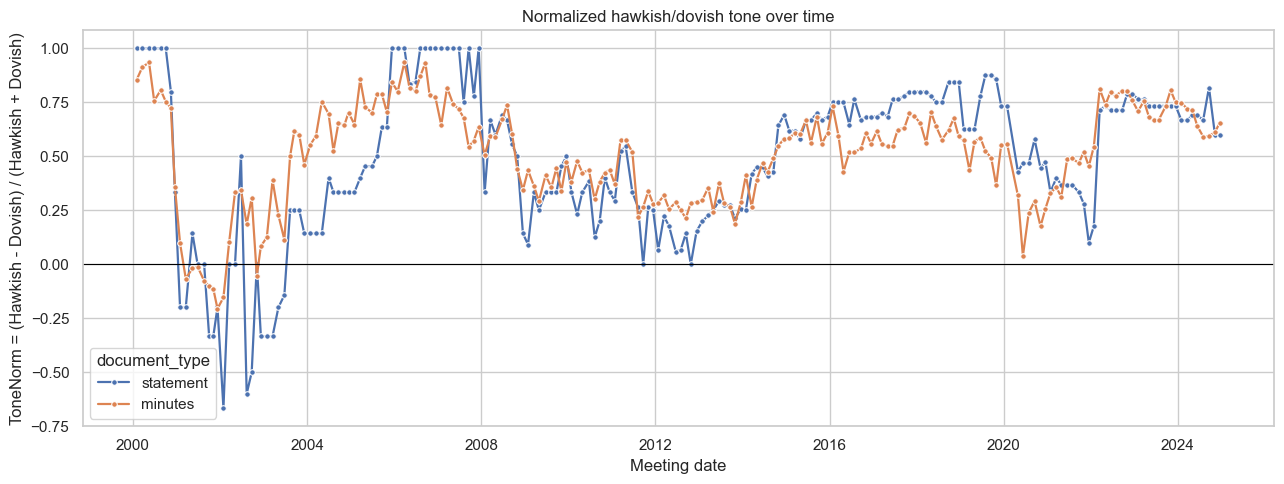

In [207]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(
    data=long_tone,
    x="date_dt",
    y="tone_norm",
    hue="document_type",
    marker="o",
    markersize=4,
    linewidth=1.6,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Normalized hawkish/dovish tone over time")
ax.set_xlabel("Meeting date")
ax.set_ylabel("ToneNorm = (Hawkish - Dovish) / (Hawkish + Dovish)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "tone_norm_over_time.png", dpi=180)
plt.show()


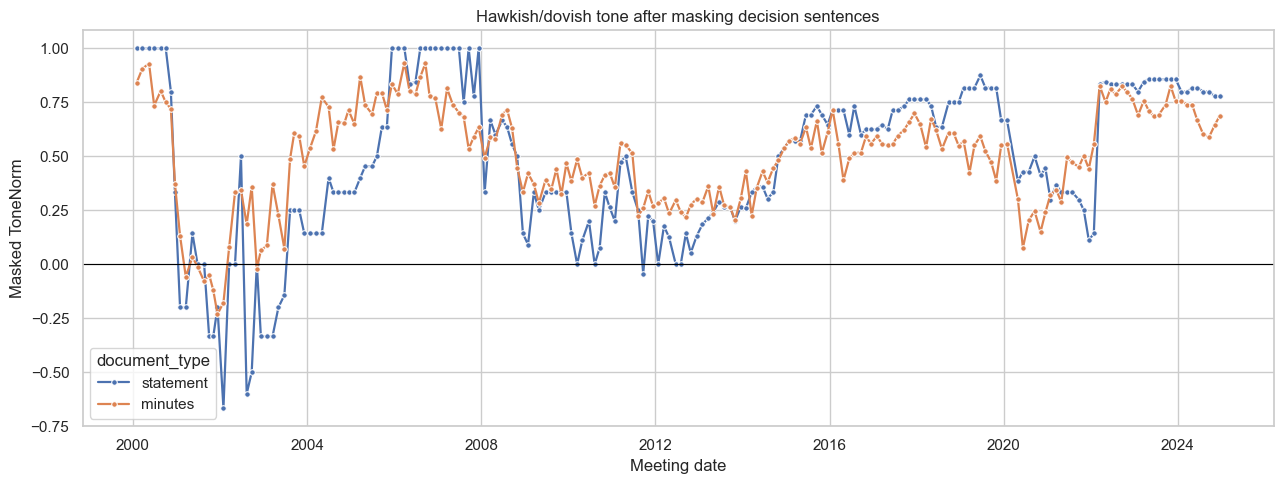

In [208]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(
    data=long_tone,
    x="date_dt",
    y="masked_tone_norm",
    hue="document_type",
    marker="o",
    markersize=4,
    linewidth=1.6,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Hawkish/dovish tone after masking decision sentences")
ax.set_xlabel("Meeting date")
ax.set_ylabel("Masked ToneNorm")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "masked_tone_norm_over_time.png", dpi=180)
plt.show()


The tone is especially hawkish in the early 2000s before the easing cycle, during the 2015-2019 normalization, and during the post-Covid inflation period. It becomes more dovish around 2001-2003 and more moderate during periods of stress. The masked score keeps the same broad pattern, suggesting that the signal is not driven only by sentences announcing the policy decision.


## 11. Result 2: statements versus minutes

Statements are the immediate official signal. Minutes are longer and more detailed. The distance below measures whether minutes confirm, soften, or amplify the statement-level signal:

\[
\text{DistanceTone}_t=|\text{ToneNorm}_{minutes,t}-\text{ToneNorm}_{statement,t}|.
\]

A positive signed gap means the minutes are more hawkish than the statement; a negative signed gap means they are more dovish.


In [209]:
paired_t = stats.ttest_rel(fomc["minutes_tone_norm"], fomc["statement_tone_norm"], nan_policy="omit")
wilcoxon = stats.wilcoxon(fomc["minutes_tone_norm"] - fomc["statement_tone_norm"])

print(f"Mean statement tone: {fomc['statement_tone_norm'].mean():.3f}")
print(f"Mean minutes tone:   {fomc['minutes_tone_norm'].mean():.3f}")
print(f"Mean distance:       {fomc['tone_distance_norm'].mean():.3f}")
print(f"Median distance:     {fomc['tone_distance_norm'].median():.3f}")
print(f"Paired t-test minutes - statements: t={paired_t.statistic:.3f}, p={paired_t.pvalue:.3f}")
print(f"Wilcoxon signed-rank: statistic={wilcoxon.statistic:.1f}, p={wilcoxon.pvalue:.3f}")

top_distance = fomc.nlargest(10, "tone_distance_norm")[
    ["date", "rate_decision", "statement_tone_norm", "minutes_tone_norm", "tone_gap_norm", "tone_distance_norm", "macro_regime"]
]
display(top_distance.round(3))


Mean statement tone: 0.484
Mean minutes tone:   0.507
Mean distance:       0.163
Median distance:     0.122
Paired t-test minutes - statements: t=1.466, p=0.144
Wilcoxon signed-rank: statistic=9481.0, p=0.564


,date,rate_decision,statement_tone_norm,minutes_tone_norm,tone_gap_norm,tone_distance_norm,macro_regime
21,2002-09-24,hold,-0.500,0.308,0.808,0.808,dotcom_2001_easing
20,2002-08-13,hold,-0.600,0.185,0.785,0.785,dotcom_2001_easing
25,2003-03-18,hold,-0.333,0.389,0.722,0.722,dotcom_2001_easing
34,2004-05-04,hold,0.143,0.753,0.610,0.610,baseline_expansion
16,2002-01-30,hold,-0.667,-0.154,0.513,0.513,dotcom_2001_easing
158,2019-10-30,cut,0.857,0.365,-0.492,0.492,normalization_2015_2019
24,2003-01-29,hold,-0.333,0.125,0.458,0.458,dotcom_2001_easing
61,2007-09-18,cut,1.000,0.543,-0.457,0.457,global_financial_crisis
41,2005-03-22,hike,0.400,0.856,0.456,0.456,baseline_expansion
33,2004-03-16,hold,0.143,0.595,0.452,0.452,baseline_expansion


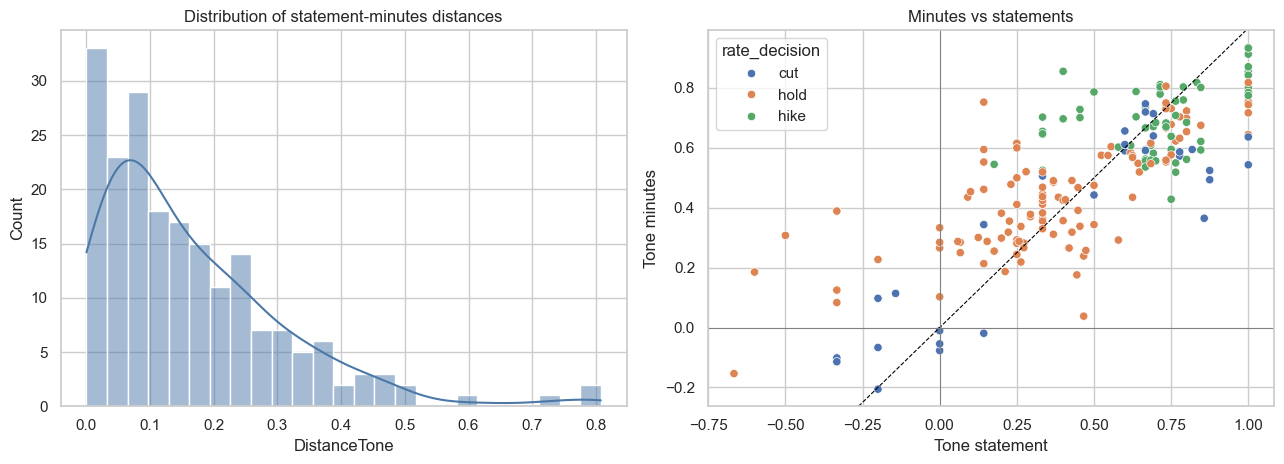

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.histplot(fomc["tone_distance_norm"], bins=25, kde=True, ax=axes[0], color="#4c78a8")
axes[0].set_title("Distribution of statement-minutes distances")
axes[0].set_xlabel("DistanceTone")

sns.scatterplot(
    data=fomc,
    x="statement_tone_norm",
    y="minutes_tone_norm",
    hue="rate_decision",
    hue_order=["cut", "hold", "hike"],
    ax=axes[1],
)
axes[1].axline((0, 0), slope=1, color="black", linewidth=0.8, linestyle="--")
axes[1].axhline(0, color="grey", linewidth=0.7)
axes[1].axvline(0, color="grey", linewidth=0.7)
axes[1].set_title("Minutes vs statements")
axes[1].set_xlabel("Tone statement")
axes[1].set_ylabel("Tone minutes")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "statement_minutes_tone_distance.png", dpi=180)
plt.show()


On average, minutes are not significantly more hawkish than statements. The mean gap is small. The meeting-level comparison is more informative: the largest distances occur mainly in the early 2000s, when some statements are quite dovish while minutes remain more balanced or still discuss inflation risks. This supports the interpretation of minutes as a contextualizing document rather than a simple repetition of the statement.


## 12. Result 3: relationship with rate decisions

A natural check is whether the tone varies with the rate decision. Hikes should be more hawkish, cuts should be less hawkish, and holds may be ambiguous because a hold can mean either a restrictive pause or a wait-and-see accommodative stance.


In [211]:
decision_summary = (
    long_tone.groupby(["document_type", "rate_decision"])["tone_norm"]
    .agg(mean="mean", median="median", std="std", count="count")
    .round(3)
)
display(decision_summary)

for corpus in ["statement", "minutes"]:
    groups = [group[f"{corpus}_tone_norm"].dropna().values for _, group in fomc.groupby("rate_decision")]
    kruskal = stats.kruskal(*groups)
    print(f"Kruskal-Wallis by rate decision - {corpus}: H={kruskal.statistic:.3f}, p={kruskal.pvalue:.3g}")


mean  median    std  count
document_type rate_decision                             
minutes       cut            0.368   0.515  0.313     30
              hike           0.700   0.697  0.120     59
              hold           0.442   0.431  0.190    110
statement     cut            0.418   0.600  0.435     30
              hike           0.705   0.714  0.202     59
              hold           0.384   0.333  0.337    110

Kruskal-Wallis by rate decision - statement: H=36.199, p=1.38e-08
Kruskal-Wallis by rate decision - minutes: H=64.387, p=1.04e-14


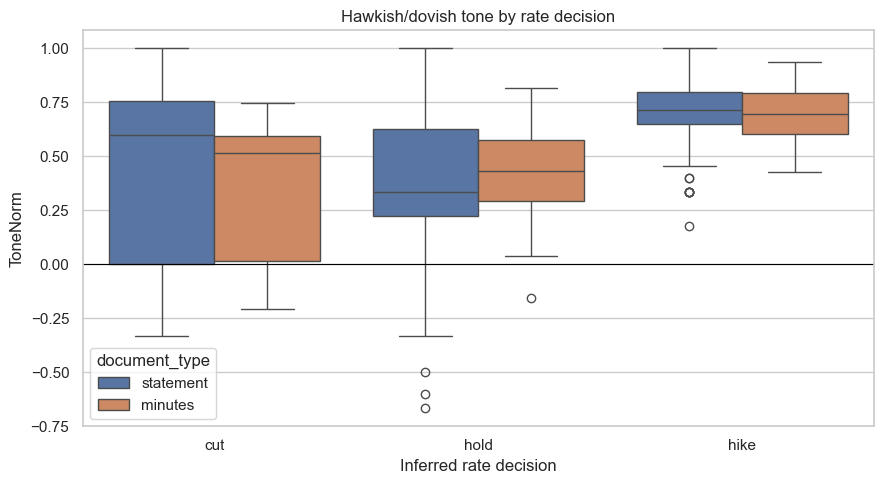

In [212]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=long_tone,
    x="rate_decision",
    y="tone_norm",
    hue="document_type",
    order=["cut", "hold", "hike"],
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Hawkish/dovish tone by rate decision")
ax.set_xlabel("Inferred rate decision")
ax.set_ylabel("ToneNorm")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "tone_by_rate_decision.png", dpi=180)
plt.show()


The relationship with decisions is clear. Hikes have the most hawkish tone. Cuts are less hawkish, but not always strongly dovish, because some cuts are still accompanied by inflation vigilance or financial-stability language. Holds are heterogeneous.


## 13. Validation experiment: quantitative checks

This section adds a more formal check. It is not causal. The goal is to see whether the lexical tone indicator behaves consistently with observed economic variables.

The first check is a descriptive regression:

\[
ToneNorm_{i,t}=\alpha+\beta_1 Minutes_i+\beta_2 Hike_t+\beta_3 Cut_t+\beta_4 VIX_t+\beta_5 Election_t+\varepsilon_{i,t}.
\]

The reference category is a statement at a hold meeting outside an election window.


In [213]:
def fit_ols(y: pd.Series, X: pd.DataFrame) -> pd.DataFrame:
    X_numeric = X.astype(float)
    y_numeric = y.astype(float)
    x_array = X_numeric.to_numpy()
    y_array = y_numeric.to_numpy()
    beta = np.linalg.lstsq(x_array, y_array, rcond=None)[0]
    fitted = x_array @ beta
    residuals = y_array - fitted
    n_obs, n_params = x_array.shape
    dof = n_obs - n_params
    sigma2 = float(residuals.T @ residuals / dof)
    cov_beta = sigma2 * np.linalg.inv(x_array.T @ x_array)
    se = np.sqrt(np.diag(cov_beta))
    t_stat = beta / se
    p_values = 2 * stats.t.sf(np.abs(t_stat), df=dof)
    return pd.DataFrame(
        {
            "coef": beta,
            "std_err": se,
            "t_stat": t_stat,
            "p_value": p_values,
        },
        index=X_numeric.columns,
    ).round(4)

regression_data = long_tone.dropna(subset=["tone_norm", "vix_window_mean"]).copy()
regression_data["const"] = 1.0
regression_data["is_minutes"] = regression_data["document_type"].eq("minutes").astype(int)
regression_data["decision_hike"] = regression_data["rate_decision"].eq("hike").astype(int)
regression_data["decision_cut"] = regression_data["rate_decision"].eq("cut").astype(int)
regression_data["vix_z"] = (
    regression_data["vix_window_mean"] - regression_data["vix_window_mean"].mean()
) / regression_data["vix_window_mean"].std()
regression_data["election_window"] = regression_data["any_election_window"].astype(int)

X_cols = ["const", "is_minutes", "decision_hike", "decision_cut", "vix_z", "election_window"]
ols_table = fit_ols(regression_data["tone_norm"], regression_data[X_cols])
display(ols_table)


,coef,std_err,t_stat,p_value
const,0.4064,0.0228,17.7987,0.0000
is_minutes,0.0226,0.0256,0.8856,0.3764
decision_hike,0.2553,0.0297,8.6028,0.0000
decision_cut,0.0117,0.0376,0.3117,0.7554
vix_z,-0.0824,0.0135,-6.0946,0.0000
election_window,0.0020,0.0293,0.0692,0.9449


The second check is a simple supervised baseline. The task is to see whether a few text variables help recover the rate-decision category better than a classifier that always predicts the majority class. Balanced accuracy is used because the classes are uneven.


In [214]:
classification_data = fomc.dropna(
    subset=["statement_tone_norm", "minutes_tone_norm", "tone_distance_norm", "vix_window_mean", "rate_decision"]
).copy()
X_classification = classification_data[
    ["statement_tone_norm", "minutes_tone_norm", "tone_distance_norm", "vix_window_mean"]
]
y_classification = classification_data["rate_decision"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "majority_baseline": DummyClassifier(strategy="most_frequent"),
    "logistic_text_context": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced"),
    ),
}

cv_rows = []
for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_classification,
        y_classification,
        cv=cv,
        scoring="balanced_accuracy",
    )
    cv_rows.append(
        {
            "model": model_name,
            "balanced_accuracy_mean": scores.mean(),
            "balanced_accuracy_std": scores.std(),
        }
    )

cv_results = pd.DataFrame(cv_rows).round(3)
display(cv_results)


,model,balanced_accuracy_mean,balanced_accuracy_std
0,majority_baseline,0.333,0.000
1,logistic_text_context,0.620,0.088


The regression confirms the main pattern: conditional on VIX and document type, hikes are associated with a more hawkish tone. The supervised check is intentionally simple. It shows that the text-based scores carry information beyond a naive baseline, but it is not meant to be a final prediction model. The rate-decision label is itself inferred from statements.


## 14. TF-IDF benchmark with a chronological split

The dictionary score is interpretable, but it is useful to compare it with a more standard NLP representation. This section evaluates TF-IDF models on the rate-decision label. The split is chronological: earlier meetings are used for training and later meetings for testing. This is stricter than a random split because policy language changes over time.

The benchmark is not the main model of the report. It is a robustness check: if TF-IDF models recover rate decisions above a naive baseline, it suggests that the corpus contains a measurable policy signal beyond the hand-built dictionary.


In [215]:
def strip_fed_boilerplate(text: str | float | None) -> str:
    """Remove recurring web-page and administrative fragments without changing the core text."""
    cleaned = str(text or "")
    cleaned = re.sub(r"Return to top.*$", " ", cleaned, flags=re.IGNORECASE | re.DOTALL)
    cleaned = re.sub(r"Home\s*\|\s*FOMC.*$", " ", cleaned, flags=re.IGNORECASE | re.DOTALL)
    cleaned = re.sub(r"Accessibility\s+To comment on this site.*$", " ", cleaned, flags=re.IGNORECASE | re.DOTALL)
    cleaned = re.sub(r"Last update:.*$", " ", cleaned, flags=re.IGNORECASE | re.DOTALL)
    cleaned = re.sub(r"\s+", " ", cleaned)
    return cleaned.strip()

for corpus in ["statement", "minutes"]:
    fomc[f"{corpus}_text_stripped"] = fomc[f"{corpus}_text"].map(strip_fed_boilerplate)
    fomc[f"{corpus}_masked_text_stripped"] = fomc[f"{corpus}_text_stripped"].map(mask_decision_sentences)

TEXT_MODEL_LABELS = ["cut", "hold", "hike"]

def chronological_split(data: pd.DataFrame, test_size: float = 0.30) -> tuple[pd.DataFrame, pd.DataFrame]:
    ordered = data.sort_values("date_dt").reset_index(drop=True)
    split_idx = int(len(ordered) * (1 - test_size))
    return ordered.iloc[:split_idx].copy(), ordered.iloc[split_idx:].copy()

def evaluate_tfidf_model(
    data: pd.DataFrame,
    text_col: str,
    target_col: str,
    estimator,
    model_name: str,
    corpus: str,
    text_version: str,
    test_size: float = 0.30,
) -> dict[str, object]:
    train, test = chronological_split(data[["date_dt", text_col, target_col]].dropna(), test_size=test_size)
    pipe = make_pipeline(
        TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, max_features=6000),
        estimator,
    )
    pipe.fit(train[text_col], train[target_col])
    pred = pipe.predict(test[text_col])
    return {
        "corpus": corpus,
        "text_version": text_version,
        "model": model_name,
        "accuracy": accuracy_score(test[target_col], pred),
        "macro_f1": f1_score(test[target_col], pred, labels=TEXT_MODEL_LABELS, average="macro", zero_division=0),
        "train_start": train["date_dt"].min().date(),
        "train_end": train["date_dt"].max().date(),
        "test_start": test["date_dt"].min().date(),
        "test_end": test["date_dt"].max().date(),
        "n_train": len(train),
        "n_test": len(test),
    }

text_versions = {
    "full": {"statement": "statement_text", "minutes": "minutes_text"},
    "masked": {"statement": "statement_masked_text", "minutes": "minutes_masked_text"},
    "stripped_masked": {"statement": "statement_masked_text_stripped", "minutes": "minutes_masked_text_stripped"},
}
model_specs = {
    "logreg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "linear_svm": LinearSVC(class_weight="balanced", max_iter=5000),
}

benchmark_rows = []
for text_version, by_corpus in text_versions.items():
    for corpus, text_col in by_corpus.items():
        for model_name, estimator in model_specs.items():
            benchmark_rows.append(
                evaluate_tfidf_model(
                    fomc,
                    text_col=text_col,
                    target_col="rate_decision",
                    estimator=estimator,
                    model_name=model_name,
                    corpus=corpus,
                    text_version=text_version,
                )
            )

majority_train, majority_test = chronological_split(fomc[["date_dt", "rate_decision"]])
majority_model = DummyClassifier(strategy="most_frequent")
majority_model.fit(majority_train[["date_dt"]], majority_train["rate_decision"])
majority_pred = majority_model.predict(majority_test[["date_dt"]])
majority_row = {
    "corpus": "none",
    "text_version": "none",
    "model": "majority_baseline",
    "accuracy": accuracy_score(majority_test["rate_decision"], majority_pred),
    "macro_f1": f1_score(majority_test["rate_decision"], majority_pred, labels=TEXT_MODEL_LABELS, average="macro", zero_division=0),
    "train_start": majority_train["date_dt"].min().date(),
    "train_end": majority_train["date_dt"].max().date(),
    "test_start": majority_test["date_dt"].min().date(),
    "test_end": majority_test["date_dt"].max().date(),
    "n_train": len(majority_train),
    "n_test": len(majority_test),
}
benchmark_results = pd.concat([pd.DataFrame([majority_row]), pd.DataFrame(benchmark_rows)], ignore_index=True)
benchmark_results = benchmark_results.sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(benchmark_results.round(3))


,corpus,text_version,model,accuracy,macro_f1,train_start,train_end,test_start,test_end,n_train,n_test
0,minutes,full,linear_svm,0.550,0.407,2000-02-02,2017-05-03,2017-06-14,2024-12-18,139,60
1,minutes,masked,linear_svm,0.550,0.401,2000-02-02,2017-05-03,2017-06-14,2024-12-18,139,60
2,minutes,stripped_masked,linear_svm,0.550,0.401,2000-02-02,2017-05-03,2017-06-14,2024-12-18,139,60
3,minutes,full,logreg,0.533,0.392,2000-02-02,2017-05-03,2017-06-14,2024-12-18,139,60
4,minutes,masked,logreg,0.533,0.384,2000-02-02,2017-05-03,2017-06-14,2024-12-18,139,60
5,minutes,stripped_masked,logreg,0.533,0.382,2000-02-02,2017-05-03,2017-06-14,2024-12-18,139,60
6,statement,full,linear_svm,0.483,0.333,2000-02-02,2017-05-03,2017-06-14,2024-12-18,139,60
7,statement,full,logreg,0.400,0.276,2000-02-02,2017-05-03,2017-06-14,2024-12-18,139,60
8,statement,masked,linear_svm,0.500,0.256,2000-02-02,2017-05-03,2017-06-14,2024-12-18,139,60
9,statement,masked,logreg,0.450,0.256,2000-02-02,2017-05-03,2017-06-14,2024-12-18,139,60


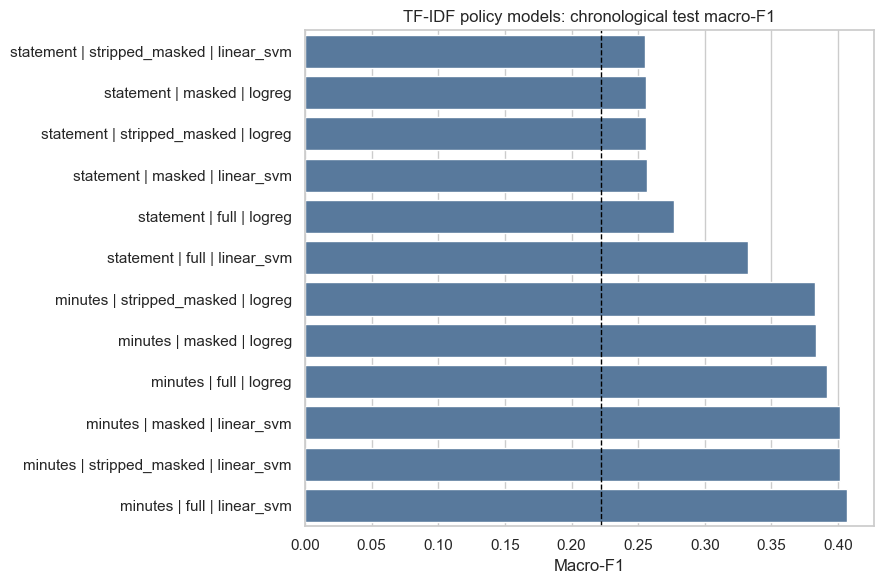

In [216]:
plot_benchmarks = benchmark_results.loc[benchmark_results["model"].ne("majority_baseline")].copy()
plot_benchmarks["setup"] = (
    plot_benchmarks["corpus"] + " | " + plot_benchmarks["text_version"] + " | " + plot_benchmarks["model"]
)
plot_benchmarks = plot_benchmarks.sort_values("macro_f1")

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=plot_benchmarks, y="setup", x="macro_f1", color="#4c78a8", ax=ax)
ax.axvline(benchmark_results.loc[benchmark_results["model"].eq("majority_baseline"), "macro_f1"].iloc[0], color="black", linestyle="--", linewidth=1)
ax.set_title("TF-IDF policy models: chronological test macro-F1")
ax.set_xlabel("Macro-F1")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "tfidf_policy_models_macro_f1.png", dpi=180)
plt.show()


The benchmark is deliberately simple. Macro-F1 is the key number because `hold` is the most frequent class. The comparison between full, masked, and stripped-masked texts checks whether the model relies only on explicit decision sentences or on broader policy language. A strong TF-IDF result does not replace the dictionary score, but it provides an external check that policy information is recoverable from the text.


## 15. TF-IDF coefficient reading

A linear model can also be used as a diagnostic tool. The next cell fits a logistic model on masked statement text and lists the terms with the largest positive coefficients for each decision class. This is descriptive: the goal is to see whether automatically learned terms align with the economic dictionary.


In [217]:
coef_text_col = "statement_masked_text_stripped"
coef_vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, max_features=6000)
coef_matrix = coef_vectorizer.fit_transform(fomc[coef_text_col])
coef_model = LogisticRegression(max_iter=2000, class_weight="balanced")
coef_model.fit(coef_matrix, fomc["rate_decision"])
terms = coef_vectorizer.get_feature_names_out()

coef_rows = []
for class_idx, label in enumerate(coef_model.classes_):
    top_idx = np.argsort(coef_model.coef_[class_idx])[-15:][::-1]
    for rank, term_idx in enumerate(top_idx, start=1):
        coef_rows.append(
            {
                "class": label,
                "rank": rank,
                "term": terms[term_idx],
                "coef": coef_model.coef_[class_idx, term_idx],
            }
        )
coef_table = pd.DataFrame(coef_rows)
display(coef_table.pivot(index="rank", columns="class", values="term"))


class,cut,hike,hold
rank,,,
1,approved,energy,purchases
2,2024,energy prices,recovery
3,discount rate,prices,economic recovery
4,discount,2022,support
5,reduction,point increase,billion
6,point reduction,declines energy,time
7,reduction discount,inflation,asset
8,action board,increase discount,securities
9,decision_masked related,supply,billion month


The coefficient table is useful for auditing the dictionary. Terms associated with `hike` should point toward inflation, prices, restrictive conditions, or labor-market strength. Terms associated with `cut` should point toward weakness, downside risks, or support. Mismatches are informative because they show where a purely lexical dictionary may miss context.


## 16. Dictionary sensitivity

Some dictionary terms are intentionally broad. Words such as `increase`, `pressure`, or `support` can carry monetary-policy meaning, but they can also appear in less specific contexts. This section recomputes the tone with a stricter dictionary that removes the most generic terms and checks whether the main conclusions are stable.


In [218]:
GENERIC_HAWKISH_TERMS = {"increase", "increased", "increases", "pressure", "pressures", "elevated"}
GENERIC_DOVISH_TERMS = {"support", "recovery", "weakness"}
STRICT_HAWKISH_TERMS = [term for term in HAWKISH_TERMS if term not in GENERIC_HAWKISH_TERMS]
STRICT_DOVISH_TERMS = [term for term in DOVISH_TERMS if term not in GENERIC_DOVISH_TERMS]

for corpus in ["statement", "minutes"]:
    h_strict = fomc[f"{corpus}_clean_text"].map(lambda text: count_dictionary_terms(text, STRICT_HAWKISH_TERMS))
    d_strict = fomc[f"{corpus}_clean_text"].map(lambda text: count_dictionary_terms(text, STRICT_DOVISH_TERMS))
    n_words = fomc[f"{corpus}_n_words"].replace(0, np.nan)
    fomc[f"{corpus}_strict_hawkish_score"] = (h_strict / n_words).fillna(0.0)
    fomc[f"{corpus}_strict_dovish_score"] = (d_strict / n_words).fillna(0.0)
    fomc[f"{corpus}_strict_tone_norm"] = normalized_balance(
        fomc[f"{corpus}_strict_hawkish_score"],
        fomc[f"{corpus}_strict_dovish_score"],
    )

sensitivity_rows = []
for corpus in ["statement", "minutes"]:
    sensitivity_rows.append(
        {
            "document_type": corpus,
            "corr_main_strict": fomc[f"{corpus}_tone_norm"].corr(fomc[f"{corpus}_strict_tone_norm"]),
            "mean_abs_difference": (fomc[f"{corpus}_tone_norm"] - fomc[f"{corpus}_strict_tone_norm"]).abs().mean(),
            "main_mean": fomc[f"{corpus}_tone_norm"].mean(),
            "strict_mean": fomc[f"{corpus}_strict_tone_norm"].mean(),
        }
    )
sensitivity_summary = pd.DataFrame(sensitivity_rows).round(3)
display(sensitivity_summary)

decision_sensitivity = []
for corpus in ["statement", "minutes"]:
    tmp = fomc.groupby("rate_decision")[[f"{corpus}_tone_norm", f"{corpus}_strict_tone_norm"]].mean().round(3)
    tmp["document_type"] = corpus
    decision_sensitivity.append(tmp.reset_index())
decision_sensitivity = pd.concat(decision_sensitivity, ignore_index=True)
display(decision_sensitivity)


,document_type,corr_main_strict,mean_abs_difference,main_mean,strict_mean
0,statement,0.839,0.159,0.484,0.614
1,minutes,0.935,0.079,0.507,0.461


,rate_decision,statement_tone_norm,statement_strict_tone_norm,document_type,minutes_tone_norm,minutes_strict_tone_norm
0,cut,0.418,0.540,statement,NaN,NaN
1,hike,0.705,0.727,statement,NaN,NaN
2,hold,0.384,0.574,statement,NaN,NaN
3,cut,NaN,NaN,minutes,0.368,0.303
4,hike,NaN,NaN,minutes,0.700,0.638
5,hold,NaN,NaN,minutes,0.442,0.410


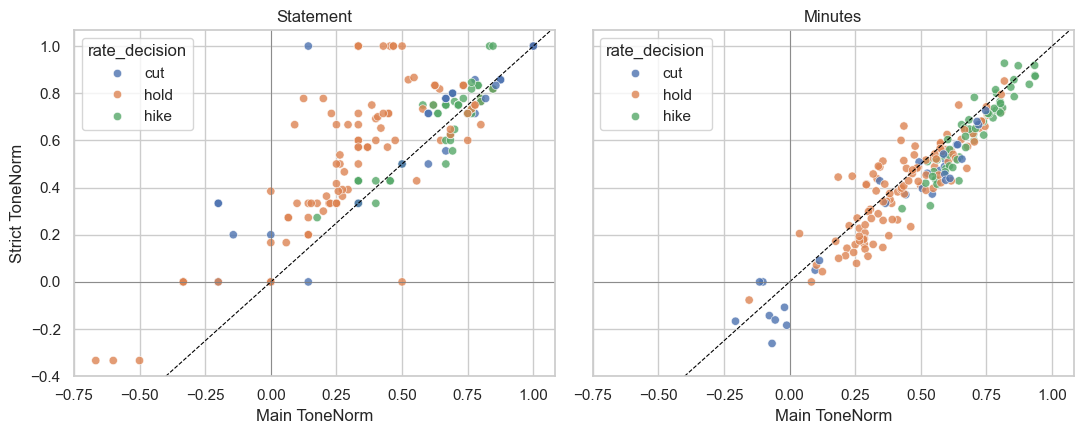

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, corpus in zip(axes, ["statement", "minutes"]):
    sns.scatterplot(
        data=fomc,
        x=f"{corpus}_tone_norm",
        y=f"{corpus}_strict_tone_norm",
        hue="rate_decision",
        hue_order=["cut", "hold", "hike"],
        alpha=0.8,
        ax=ax,
    )
    ax.axline((0, 0), slope=1, color="black", linestyle="--", linewidth=0.8)
    ax.axhline(0, color="grey", linewidth=0.6)
    ax.axvline(0, color="grey", linewidth=0.6)
    ax.set_title(corpus.capitalize())
    ax.set_xlabel("Main ToneNorm")
    ax.set_ylabel("Strict ToneNorm")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "dictionary_sensitivity.png", dpi=180)
plt.show()


If the strict score is highly correlated with the main score and preserves the ordering by rate decision, the main conclusions do not depend on the most generic terms. If the strict score changes specific meetings, those cases are useful for qualitative inspection.


## 17. Dense document embeddings: LSA robustness check

The dictionary and TF-IDF models focus on explicit lexical markers. A dense document representation provides a complementary view: documents can be compared by their position in a lower-dimensional semantic space. This section uses LSA embeddings, obtained by applying truncated SVD to a TF-IDF matrix.

The goal is not to replace Sentence-BERT or modern contextual embeddings. LSA is used because it is lightweight, reproducible, and already fits the project dependencies. It lets us ask three questions:

1. Does the document geometry separate statements and minutes, or policy regimes?
2. Are documents closer to a hawkish prototype also higher on the dictionary tone score?
3. Do nearest neighbors in the embedding space correspond to economically similar meetings?


In [220]:
def document_excerpt(text: str | float | None, max_words: int = 450) -> str:
    """Use a beginning/middle/end excerpt so long minutes fit in a compact embedding input."""
    words = clean_text(strip_fed_boilerplate(text)).split()
    if len(words) <= max_words:
        return " ".join(words)
    block = max_words // 3
    middle_start = max(0, len(words) // 2 - block // 2)
    excerpt_words = words[:block] + words[middle_start:middle_start + block] + words[-block:]
    return " ".join(excerpt_words)

embedding_rows = []
for corpus in ["statement", "minutes"]:
    for _, row in fomc.iterrows():
        embedding_rows.append(
            {
                "date": row["date"],
                "date_dt": row["date_dt"],
                "year": row["year"],
                "document_type": corpus,
                "rate_decision": row["rate_decision"],
                "macro_regime": row["macro_regime"],
                "tone_norm": row[f"{corpus}_tone_norm"],
                "strict_tone_norm": row.get(f"{corpus}_strict_tone_norm", np.nan),
                "mandate_balance": row[f"{corpus}_mandate_balance"],
                "embedding_text": document_excerpt(row[f"{corpus}_text"]),
            }
        )
embedding_df = pd.DataFrame(embedding_rows)

lsa_vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, max_features=8000)
lsa_tfidf = lsa_vectorizer.fit_transform(embedding_df["embedding_text"])
n_components = min(30, lsa_tfidf.shape[0] - 1, lsa_tfidf.shape[1] - 1)
lsa_model = TruncatedSVD(n_components=n_components, random_state=42)
lsa_vectors = lsa_model.fit_transform(lsa_tfidf)

lsa_pca = PCA(n_components=2, random_state=42)
lsa_coords = lsa_pca.fit_transform(lsa_vectors)
embedding_df["lsa_x"] = lsa_coords[:, 0]
embedding_df["lsa_y"] = lsa_coords[:, 1]

hawkish_prototype = "inflation pressures restrictive monetary policy tightening higher interest rates price stability"
dovish_prototype = "support growth labor market weakness unemployment easing lower interest rates downside risks"
prototype_tfidf = lsa_vectorizer.transform([hawkish_prototype, dovish_prototype])
prototype_lsa = lsa_model.transform(prototype_tfidf)
embedding_df["lsa_hawkish_similarity"] = cosine_similarity(lsa_vectors, prototype_lsa[[0]]).ravel()
embedding_df["lsa_dovish_similarity"] = cosine_similarity(lsa_vectors, prototype_lsa[[1]]).ravel()
embedding_df["lsa_prototype_tone"] = embedding_df["lsa_hawkish_similarity"] - embedding_df["lsa_dovish_similarity"]

lsa_corr_rows = []
for doc_type, subset in embedding_df.groupby("document_type"):
    lsa_corr_rows.append(
        {
            "document_type": doc_type,
            "corr_lsa_dictionary_tone": subset["lsa_prototype_tone"].corr(subset["tone_norm"]),
            "corr_lsa_mandate_balance": subset["lsa_prototype_tone"].corr(subset["mandate_balance"]),
            "n": len(subset),
        }
    )
lsa_corr = pd.DataFrame(lsa_corr_rows).round(3)
display(lsa_corr)
print(f"Explained variance ratio, first {n_components} LSA components: {lsa_model.explained_variance_ratio_.sum():.3f}")


,document_type,corr_lsa_dictionary_tone,corr_lsa_mandate_balance,n
0,minutes,0.150,0.205,199
1,statement,0.407,-0.151,199


Explained variance ratio, first 30 LSA components: 0.515


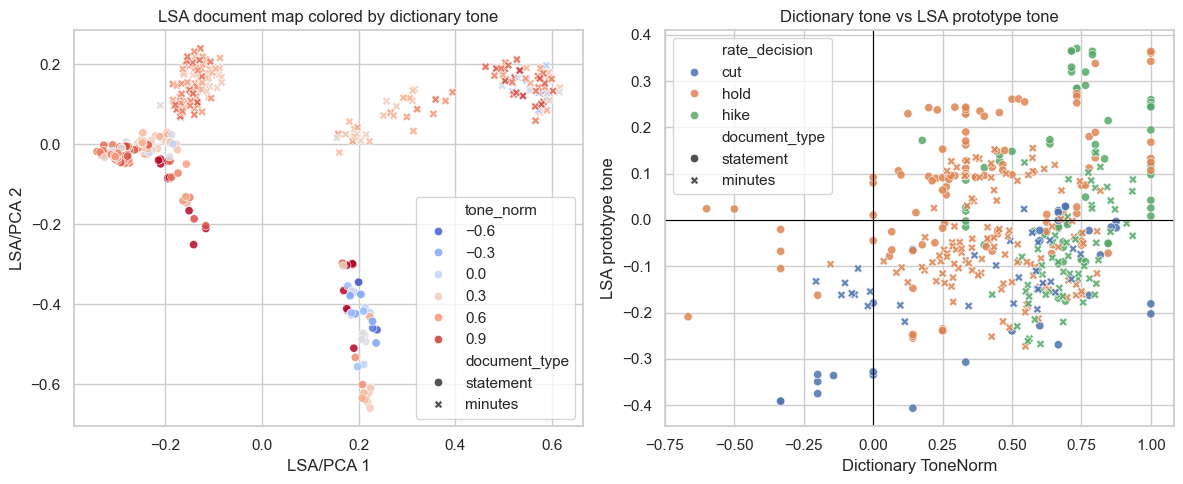

In [221]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=embedding_df,
    x="lsa_x",
    y="lsa_y",
    hue="tone_norm",
    style="document_type",
    palette="coolwarm",
    alpha=0.85,
    ax=axes[0],
)
axes[0].set_title("LSA document map colored by dictionary tone")
axes[0].set_xlabel("LSA/PCA 1")
axes[0].set_ylabel("LSA/PCA 2")

sns.scatterplot(
    data=embedding_df,
    x="tone_norm",
    y="lsa_prototype_tone",
    hue="rate_decision",
    style="document_type",
    hue_order=["cut", "hold", "hike"],
    alpha=0.85,
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Dictionary tone vs LSA prototype tone")
axes[1].set_xlabel("Dictionary ToneNorm")
axes[1].set_ylabel("LSA prototype tone")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "lsa_embedding_robustness.png", dpi=180)
plt.show()


The LSA prototype score is a semantic robustness check. If it is positively correlated with the dictionary tone, then documents that are close to a hawkish prototype in the dense space also tend to have more hawkish dictionary language. If the correlation is weak, the dense representation may be capturing broader document structure rather than the specific policy signal.


## 18. Nearest neighbors in LSA space

Nearest neighbors provide a qualitative check on the embedding geometry. For selected meetings, the table below lists the closest documents in cosine similarity. Economically coherent neighbors suggest that the dense representation captures meaningful policy regimes or communication episodes.


In [222]:
lsa_norms = np.linalg.norm(lsa_vectors, axis=1, keepdims=True)
lsa_vectors_normed = np.divide(lsa_vectors, lsa_norms, out=np.zeros_like(lsa_vectors), where=lsa_norms != 0)

def nearest_lsa_documents(query_date: str, document_type: str, n: int = 6) -> pd.DataFrame:
    mask = embedding_df["date"].eq(query_date) & embedding_df["document_type"].eq(document_type)
    if not mask.any():
        return pd.DataFrame()
    query_idx = embedding_df.index[mask][0]
    similarities = cosine_similarity(lsa_vectors_normed[[query_idx]], lsa_vectors_normed).ravel()
    order = np.argsort(similarities)[::-1]
    order = [idx for idx in order if idx != query_idx][:n]
    output = embedding_df.loc[order, ["date", "document_type", "rate_decision", "macro_regime", "tone_norm", "lsa_prototype_tone", "embedding_text"]].copy()
    output["lsa_similarity"] = similarities[order]
    output["excerpt"] = output["embedding_text"].str.slice(0, 220)
    return output.drop(columns=["embedding_text"]).round({"tone_norm": 3, "lsa_prototype_tone": 3, "lsa_similarity": 3})

query_cases = [
    ("2008-12-16", "statement"),
    ("2020-04-29", "statement"),
    ("2022-06-15", "minutes"),
]
for query_date, document_type in query_cases:
    neighbors = nearest_lsa_documents(query_date, document_type, n=6)
    if not neighbors.empty:
        print(f"Nearest LSA neighbors for {query_date} {document_type}")
        display(neighbors)


Nearest LSA neighbors for 2008-12-16 statement


,date,document_type,rate_decision,macro_regime,tone_norm,lsa_prototype_tone,lsa_similarity,excerpt
70,2008-10-29,statement,cut,global_financial_crisis,0.500,-0.240,0.921,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
72,2009-01-28,statement,hold,global_financial_crisis,0.091,0.106,0.917,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
62,2007-10-31,statement,cut,global_financial_crisis,0.778,-0.163,0.883,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
66,2008-04-30,statement,cut,global_financial_crisis,0.600,-0.228,0.870,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
61,2007-09-18,statement,cut,global_financial_crisis,1.000,-0.203,0.870,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
64,2008-01-30,statement,cut,global_financial_crisis,0.333,-0.307,0.861,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...


Nearest LSA neighbors for 2020-04-29 statement


,date,document_type,rate_decision,macro_regime,tone_norm,lsa_prototype_tone,lsa_similarity,excerpt
162,2020-06-10,statement,hold,covid_crisis,0.467,0.119,0.999,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
163,2020-07-29,statement,hold,covid_crisis,0.467,0.108,0.996,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
164,2020-09-16,statement,hold,covid_crisis,0.579,0.104,0.920,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
166,2020-12-16,statement,hold,covid_crisis,0.474,0.150,0.879,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
165,2020-11-05,statement,hold,covid_crisis,0.444,0.149,0.878,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
175,2022-01-26,statement,hike,post_covid_inflation_tightening,0.176,0.172,0.868,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...


Nearest LSA neighbors for 2022-06-15 minutes


,date,document_type,rate_decision,macro_regime,tone_norm,lsa_prototype_tone,lsa_similarity,excerpt
379,2022-09-21,minutes,hike,post_covid_inflation_tightening,0.804,-0.138,0.984,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
383,2023-03-22,minutes,hike,post_covid_inflation_tightening,0.756,-0.178,0.979,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
346,2018-06-13,minutes,hike,normalization_2015_2019,0.639,-0.155,0.967,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
338,2017-06-14,minutes,hike,normalization_2015_2019,0.550,-0.154,0.964,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
378,2022-07-27,minutes,hike,post_covid_inflation_tightening,0.780,-0.126,0.963,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...
348,2018-09-26,minutes,hike,normalization_2015_2019,0.622,-0.161,0.960,skip to main content an official website of the united states government here's how you know official websites use .gov a .gov website belongs to an officia...


The nearest-neighbor tables should be read qualitatively. They are useful when they retrieve documents from the same crisis, easing cycle, or inflation episode. They are less useful if they mostly separate statements from minutes, because that would mean the embedding geometry is dominated by document format rather than policy content.


## 19. Optional Sentence-BERT check

Sentence-BERT would provide contextual embeddings that are richer than LSA. To keep the notebook reproducible without new dependencies, the cell below is optional. If `sentence-transformers` is installed, it computes a prototype-based Sentence-BERT tone score. If not, the cell is skipped and the LSA section remains the main embedding robustness check.


In [223]:
try:
    from sentence_transformers import SentenceTransformer
    sbert_available = True
except ImportError:
    sbert_available = False

if not sbert_available:
    print("sentence-transformers is not installed; skipping optional Sentence-BERT check.")
    print("To run it locally: pip install sentence-transformers")
else:
    sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
    sbert_vectors = sbert_model.encode(embedding_df["embedding_text"].tolist(), normalize_embeddings=True, show_progress_bar=False)
    sbert_prototypes = sbert_model.encode([hawkish_prototype, dovish_prototype], normalize_embeddings=True, show_progress_bar=False)
    embedding_df["sbert_hawkish_similarity"] = cosine_similarity(sbert_vectors, sbert_prototypes[[0]]).ravel()
    embedding_df["sbert_dovish_similarity"] = cosine_similarity(sbert_vectors, sbert_prototypes[[1]]).ravel()
    embedding_df["sbert_prototype_tone"] = embedding_df["sbert_hawkish_similarity"] - embedding_df["sbert_dovish_similarity"]
    sbert_corr = (
        embedding_df.groupby("document_type")
        .apply(lambda x: pd.Series({"corr_sbert_dictionary_tone": x["sbert_prototype_tone"].corr(x["tone_norm"])}))
        .reset_index()
        .round(3)
    )
    display(sbert_corr)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9895.17it/s]


,document_type,corr_sbert_dictionary_tone
0,minutes,0.048
1,statement,0.043


## 20. Result 4: financial volatility and VIX

The VIX tests whether the Fed's signal changes in stressful financial environments. Meetings in the top quartile of meeting-window VIX are compared with all other meetings.


In [224]:
vix_summary = (
    long_tone.groupby(["document_type", "high_vix_q75"])["tone_norm"]
    .agg(mean="mean", median="median", std="std", count="count")
    .round(3)
)
display(vix_summary)

for corpus in ["statement", "minutes"]:
    high = fomc.loc[fomc["high_vix_q75"], f"{corpus}_tone_norm"]
    other = fomc.loc[~fomc["high_vix_q75"], f"{corpus}_tone_norm"]
    test = stats.ttest_ind(high, other, equal_var=False)
    print(
        f"{corpus}: high VIX mean - other mean = {high.mean() - other.mean():.3f}, "
        f"t={test.statistic:.3f}, p={test.pvalue:.3g}"
    )


mean  median    std  count
document_type high_vix_q75                             
minutes       False         0.549   0.582  0.206    149
              True          0.382   0.350  0.268     50
statement     False         0.542   0.636  0.317    149
              True          0.311   0.333  0.391     50

statement: high VIX mean - other mean = -0.231, t=-3.782, p=0.000319
minutes: high VIX mean - other mean = -0.167, t=-4.021, p=0.000145


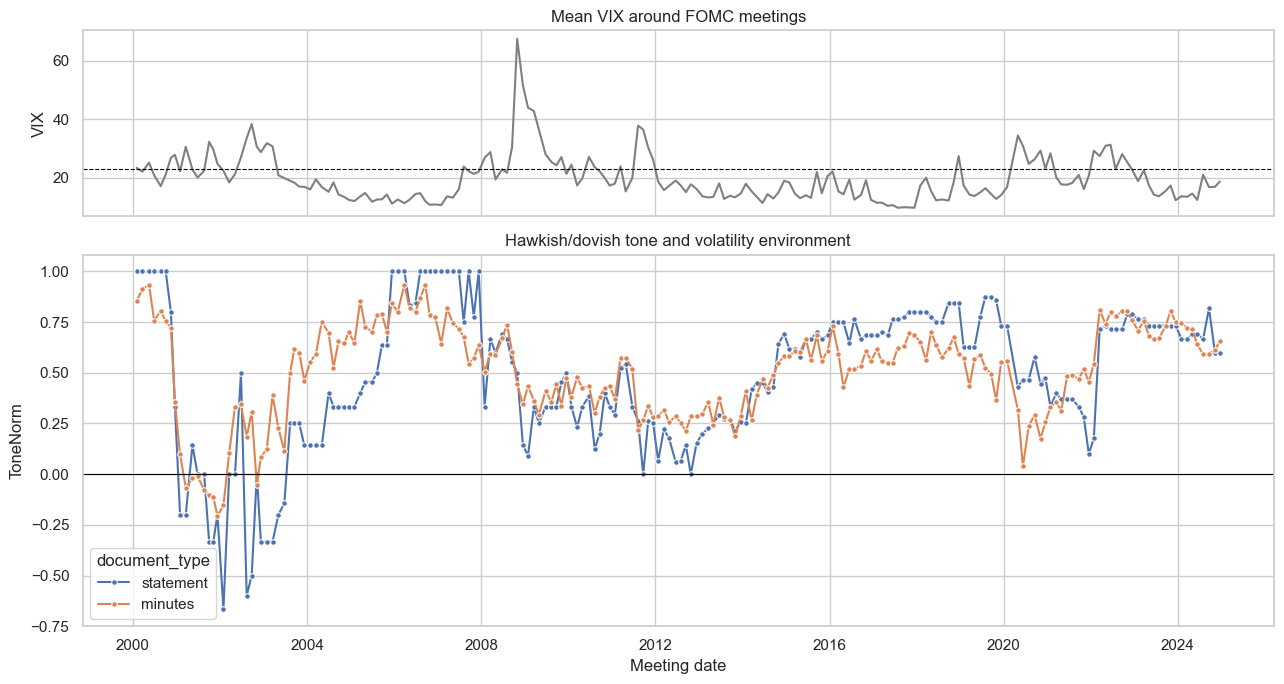

In [225]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [1, 2]})

sns.lineplot(data=fomc, x="date_dt", y="vix_window_mean", color="#7f7f7f", ax=axes[0])
axes[0].axhline(fomc["vix_window_mean"].quantile(0.75), color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Mean VIX around FOMC meetings")
axes[0].set_ylabel("VIX")
axes[0].set_xlabel("")

sns.lineplot(
    data=long_tone,
    x="date_dt",
    y="tone_norm",
    hue="document_type",
    marker="o",
    markersize=4,
    linewidth=1.5,
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Hawkish/dovish tone and volatility environment")
axes[1].set_xlabel("Meeting date")
axes[1].set_ylabel("ToneNorm")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "tone_and_vix_over_time.png", dpi=180)
plt.show()


High-volatility meetings have a lower average hawkish tone. This is consistent with a communication style that gives more weight to risk management, support, and caution in periods of financial stress. The result should not be read causally: VIX and communication likely respond to the same macro-financial environment.


## 21. Result 5: election windows

This is an exploratory political-context check. Meetings within 90 days of U.S. presidential or midterm elections are compared with other meetings.


In [226]:
election_summary = (
    long_tone.groupby(["document_type", "any_election_window"])["tone_norm"]
    .agg(mean="mean", median="median", std="std", count="count")
    .round(3)
)
display(election_summary)

for flag in ["presidential_election_window", "midterm_election_window", "any_election_window"]:
    print(f"\n{flag}")
    display(
        long_tone.groupby(["document_type", flag])["tone_norm"]
        .agg(mean="mean", median="median", count="count")
        .round(3)
    )


mean  median    std  count
document_type any_election_window                             
minutes       False                0.511   0.553  0.239    145
              True                 0.497   0.554  0.222     54
statement     False                0.494   0.524  0.334    145
              True                 0.459   0.528  0.393     54


presidential_election_window


mean  median  count
document_type presidential_election_window                      
minutes       False                         0.512   0.557    171
              True                          0.479   0.531     28
statement     False                         0.490   0.579    171
              True                          0.451   0.459     28


midterm_election_window


mean  median  count
document_type midterm_election_window                      
minutes       False                    0.506   0.553    173
              True                     0.517   0.578     26
statement     False                    0.487   0.500    173
              True                     0.469   0.634     26


any_election_window


mean  median  count
document_type any_election_window                      
minutes       False                0.511   0.553    145
              True                 0.497   0.554     54
statement     False                0.494   0.524    145
              True                 0.459   0.528     54

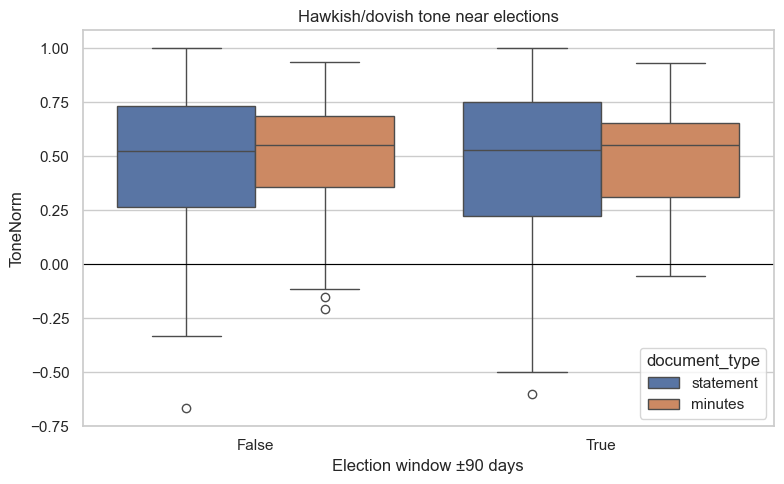

In [227]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=long_tone, x="any_election_window", y="tone_norm", hue="document_type", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Hawkish/dovish tone near elections")
ax.set_xlabel("Election window ±90 days")
ax.set_ylabel("ToneNorm")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "tone_by_election_window.png", dpi=180)
plt.show()


The differences around elections are small in this descriptive measure. In this sample, the hawkish/dovish signal appears to be more structured by rate cycles, inflation, and volatility than by the election calendar. A causal claim would require a separate identification strategy.


## 22. Result 6: macroeconomic regimes

The regimes are historical bins used for interpretation. They are not estimated by a model.


In [228]:
regime_summary = (
    long_tone.groupby(["document_type", "macro_regime"])["tone_norm"]
    .agg(mean="mean", median="median", std="std", count="count")
    .round(3)
    .sort_index()
)
display(regime_summary)


mean  median    std  count
document_type macro_regime                                                
minutes       baseline_expansion               0.723   0.744  0.133     41
              covid_crisis                     0.251   0.275  0.103      8
              dotcom_2001_easing               0.075   0.090  0.179     20
              global_financial_crisis          0.526   0.558  0.132     16
              normalization_2015_2019          0.580   0.576  0.080     33
              post_covid_inflation_tightening  0.661   0.696  0.129     30
              zlb_recovery                     0.399   0.382  0.130     51
statement     baseline_expansion               0.659   0.733  0.336     41
              covid_crisis                     0.449   0.456  0.070      8
              dotcom_2001_easing              -0.187  -0.200  0.268     20
              global_financial_crisis          0.543   0.578  0.278     16
              normalization_2015_2019          0.750   0.750  0.073     33
              post_covid_inflation_tightening  0.617   0.714  0.198     30
              zlb_recovery                     0.344   0.333  0.190     51

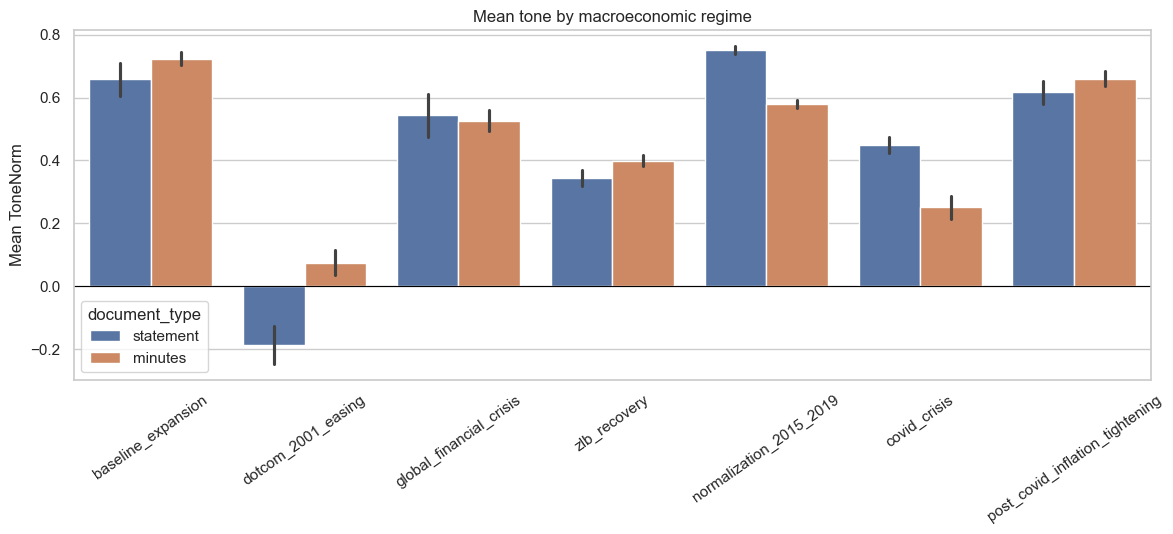

In [229]:
regime_order = [
    "baseline_expansion",
    "dotcom_2001_easing",
    "global_financial_crisis",
    "zlb_recovery",
    "normalization_2015_2019",
    "covid_crisis",
    "post_covid_inflation_tightening",
]

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.barplot(
    data=long_tone,
    x="macro_regime",
    y="tone_norm",
    hue="document_type",
    order=regime_order,
    errorbar="se",
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Mean tone by macroeconomic regime")
ax.set_xlabel("")
ax.set_ylabel("Mean ToneNorm")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "tone_by_macro_regime.png", dpi=180)
plt.show()


The dot-com/easing period in the early 2000s is the most dovish, especially in statements. Normalization and the post-Covid inflation tightening period are clearly more hawkish. The Covid crisis is more moderate, with more language around support and risks.


## 23. Sentence-level analysis

The document-level score is complemented with a sentence-level check. Sentences containing hawkish and/or dovish terms are tagged to verify that the dictionary captures interpretable policy language rather than isolated word counts only.


In [230]:
hawkish_patterns = [_term_pattern(term) for term in HAWKISH_TERMS]
dovish_patterns = [_term_pattern(term) for term in DOVISH_TERMS]

def classify_policy_sentence(sentence: str) -> str:
    cleaned = clean_text(sentence)
    is_hawkish = any(pattern.search(cleaned) for pattern in hawkish_patterns)
    is_dovish = any(pattern.search(cleaned) for pattern in dovish_patterns)
    if is_hawkish and is_dovish:
        return "mixed"
    if is_hawkish:
        return "hawkish"
    if is_dovish:
        return "dovish"
    return "none"

sentence_rows = []
example_rows = []
for _, meeting in fomc.iterrows():
    for corpus in ["statement", "minutes"]:
        sentences = split_sentences(meeting[f"{corpus}_text"])
        labels = [classify_policy_sentence(sentence) for sentence in sentences]
        counts = pd.Series(labels).value_counts()
        hawkish_n = int(counts.get("hawkish", 0))
        dovish_n = int(counts.get("dovish", 0))
        mixed_n = int(counts.get("mixed", 0))
        policy_n = hawkish_n + dovish_n + mixed_n
        denominator = hawkish_n + dovish_n
        sentence_rows.append(
            {
                "date": meeting["date"],
                "year": meeting["year"],
                "rate_decision": meeting["rate_decision"],
                "document_type": corpus,
                "n_sentences": len(sentences),
                "policy_sentence_share": policy_n / len(sentences) if sentences else 0,
                "sentence_tone_balance": (hawkish_n - dovish_n) / denominator if denominator else 0,
                "hawkish_sentences": hawkish_n,
                "dovish_sentences": dovish_n,
                "mixed_sentences": mixed_n,
            }
        )
        for sentence, label in zip(sentences, labels):
            if label in {"hawkish", "dovish", "mixed"} and len(example_rows) < 20:
                example_rows.append(
                    {
                        "date": meeting["date"],
                        "document_type": corpus,
                        "label": label,
                        "sentence": sentence[:350],
                    }
                )

sentence_df = pd.DataFrame(sentence_rows)
examples_df = pd.DataFrame(example_rows)

display(
    sentence_df.groupby("document_type")[["policy_sentence_share", "sentence_tone_balance"]]
    .agg(["mean", "median"])
    .round(3)
)
display(
    sentence_df.groupby(["document_type", "rate_decision"])["sentence_tone_balance"]
    .agg(mean="mean", median="median", count="count")
    .round(3)
)
display(examples_df.head(10))


policy_sentence_share        sentence_tone_balance       
                               mean median                  mean median
document_type                                                          
minutes                       0.297  0.303                 0.516  0.546
statement                     0.310  0.320                 0.519  0.600

mean  median  count
document_type rate_decision                      
minutes       cut            0.355   0.506     30
              hike           0.692   0.704     59
              hold           0.465   0.459    110
statement     cut            0.423   0.556     30
              hike           0.717   0.667     59
              hold           0.438   0.500    110

,date,document_type,label,sentence
0,2000-02-02,statement,hawkish,"In a related action, the Board of Governors approved a 25 basis point increase in the discount rate to 5-1/4 percent."
1,2000-02-02,statement,hawkish,"The Committee remains concerned that over time increases in demand will continue to exceed the growth in potential supply, even after taking account of the ..."
2,2000-02-02,statement,hawkish,"Against the background of its long-run goals of price stability and sustainable economic growth and of the information currently available, the Committee be..."
3,2000-02-02,minutes,hawkish,"As had previously been agreed, the temporary authority given to the Federal Reserve Bank of New York to sell options to counter potential century-data-chang..."
4,2000-02-02,minutes,hawkish,Government and Federal agency securities held in such Account (including forward commitments) at the close of business on the day of a meeting of the Commit...
5,2000-02-02,minutes,hawkish,"In the execution of the Committee's decision regarding policy during any intermeeting period, the Committee authorizes and directs the Federal Reserve Bank ..."
6,2000-02-02,minutes,hawkish,Any such adjustment shall be made in the context of the Committee's discussion and decision at its most recent meeting and the Committee's long-run objectiv...
7,2000-02-02,minutes,dovish,"First, the independence of monetary policy is jeopardized if the System adjusts its policy actions to support short-term foreign exchange objectives set by ..."
8,2000-02-02,minutes,hawkish,"Domestically, industrial production and nonfarm payrolls had continued to increase briskly."
9,2000-02-02,minutes,hawkish,"Consumer price inflation had stayed moderate over the past few months, despite a recent resurgence in energy prices."


The sentence-level classification recovers the same gradient as the document score. Hike meetings have a more hawkish balance of policy-relevant sentences. This provides a minimal qualitative validation of the dictionary approach and yields examples for qualitative inspection.


## 24. Linking macro diagnosis and policy signal

Each meeting is placed in a two-dimensional space: inflation/employment balance on the horizontal axis and hawkish/dovish tone on the vertical axis. This separates the macroeconomic topic emphasized by the Fed from the policy signal it sends.


Correlation mandate balance / tone - statement: -0.042
Correlation mandate balance / tone - minutes: 0.405


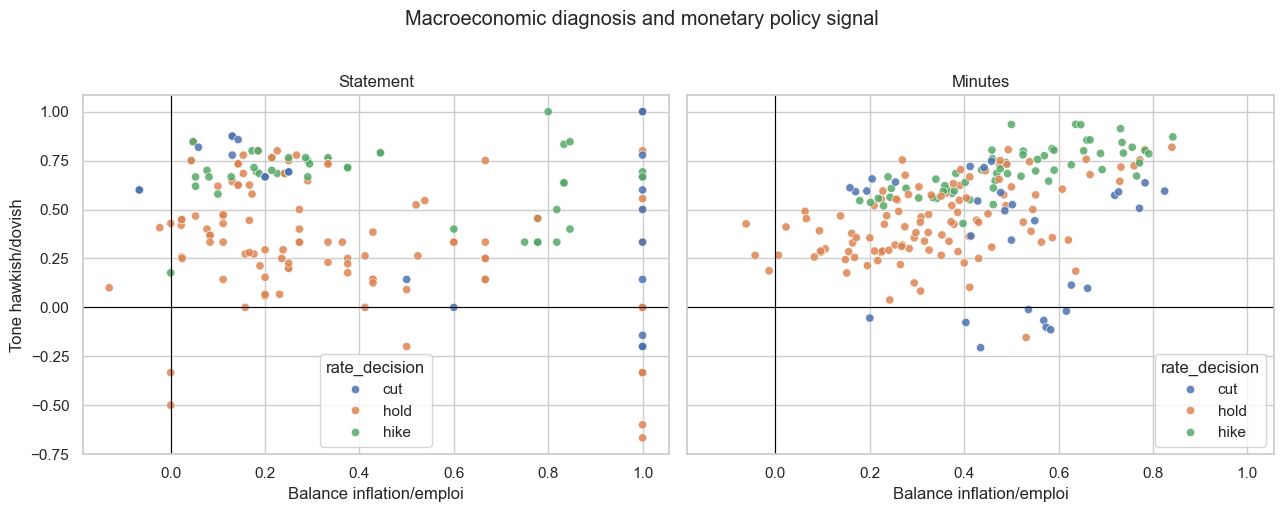

In [231]:
mandate_long_rows = []
for corpus in ["statement", "minutes"]:
    tmp = fomc[
        ["date", "date_dt", "year", "rate_decision", "macro_regime", "vix_window_mean"]
    ].copy()
    tmp["document_type"] = corpus
    tmp["tone_norm"] = fomc[f"{corpus}_tone_norm"]
    tmp["mandate_balance"] = fomc[f"{corpus}_mandate_balance"]
    mandate_long_rows.append(tmp)
mandate_long = pd.concat(mandate_long_rows, ignore_index=True)

for corpus in ["statement", "minutes"]:
    subset = mandate_long.loc[mandate_long["document_type"].eq(corpus)]
    print(
        f"Correlation mandate balance / tone - {corpus}: "
        f"{subset['mandate_balance'].corr(subset['tone_norm']):.3f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, corpus in zip(axes, ["statement", "minutes"]):
    subset = mandate_long.loc[mandate_long["document_type"].eq(corpus)]
    sns.scatterplot(
        data=subset,
        x="mandate_balance",
        y="tone_norm",
        hue="rate_decision",
        hue_order=["cut", "hold", "hike"],
        alpha=0.85,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(corpus.capitalize())
    ax.set_xlabel("Balance inflation/emploi")
    ax.set_ylabel("Tone hawkish/dovish")

fig.suptitle("Macroeconomic diagnosis and monetary policy signal", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "mandate_balance_vs_tone.png", dpi=180)
plt.show()


In [232]:
def communication_quadrant(row: pd.Series) -> str:
    if row["mandate_balance"] >= 0 and row["tone_norm"] >= 0:
        return "inflation_hawkish"
    if row["mandate_balance"] >= 0 and row["tone_norm"] < 0:
        return "inflation_dovish"
    if row["mandate_balance"] < 0 and row["tone_norm"] >= 0:
        return "employment_hawkish"
    return "employment_dovish"

mandate_long["communication_quadrant"] = mandate_long.apply(communication_quadrant, axis=1)
quadrant_table = pd.crosstab(
    mandate_long["communication_quadrant"],
    mandate_long["document_type"],
    normalize="columns",
)
display(quadrant_table.fillna(0).round(3))


document_type,minutes,statement
communication_quadrant,,
employment_hawkish,0.015,0.020
inflation_dovish,0.045,0.065
inflation_hawkish,0.940,0.915


The cross-plot shows that hawkish tone is not mechanically identical to inflation salience. The relationship is stronger in minutes than in statements. This suggests that minutes connect economic diagnosis and policy arguments more explicitly, while statements compress the institutional message.


## 25. Robustness and limitations

The analysis is transparent but limited. Dictionary scores depend on the chosen terms. Some words can be ambiguous in context. Minutes are much longer than statements, so length normalization helps but does not remove all differences. The masked score checks that the result is not only driven by explicit decision sentences. The strict dictionary, TF-IDF benchmark, and LSA embedding checks test whether the conclusions are sensitive to broad terms or to the chosen representation. The VIX, election, and regime analyses are descriptive and should not be interpreted as causal estimates. A stronger extension would require manual sentence annotations or a supervised model trained on expert labels.


## 26. Conclusion

The notebook measures the hawkish/dovish signal in FOMC statements and minutes using an interpretable NLP approach. The indicator behaves consistently with monetary policy cycles: hikes are more hawkish, high-volatility periods are less hawkish, and election windows do not show a strong descriptive effect. Minutes are not simply longer statements; they sometimes contextualize or soften the immediate signal.

The link with the inflation/employment balance shows that macro diagnosis and policy signal are related but not identical. The diagnostic axis captures what the Fed emphasizes; the hawkish/dovish axis captures the policy orientation conveyed by that language.
